In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

from astropy.io import fits

from scipy.optimize import curve_fit

In [2]:
pathdata = '/home/sophie-stucki/Documents/starsim_simulations/nina_spec/'
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun_mps.conf"

In [3]:
def simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.active_region_types=type_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][0]=type_list[j]
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [4]:
type_list = [0]
spot_size_list = [10]
latitude_list = [90]
longitude_list = [250]

period = 25
periods_nbr = 0.8
point_nbr = 5
bb_ratio = 1
t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))

In [5]:
mask = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/spectra_masks/lowres_mask.txt')

print(np.shape(mask.astype(bool)))


(4197,)


In [6]:
ss_mps = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_mps.phoenix_spectra = 0
ss_mps.convective_shift = 0
ss_mps.compute_forward(observables=['lc', 'rv'],t=t)

MPS-ATLAS spectra
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%ELSE
ELSE
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot

In [7]:
ss_phoenix_blue = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_phoenix_blue.phoenix_spectra = 1
ss_phoenix_blue.convective_shift= 0
ss_phoenix_blue.compute_forward(observables=['lc', 'rv'],t=t)

PHOENIX spectra
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%RV shift
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%

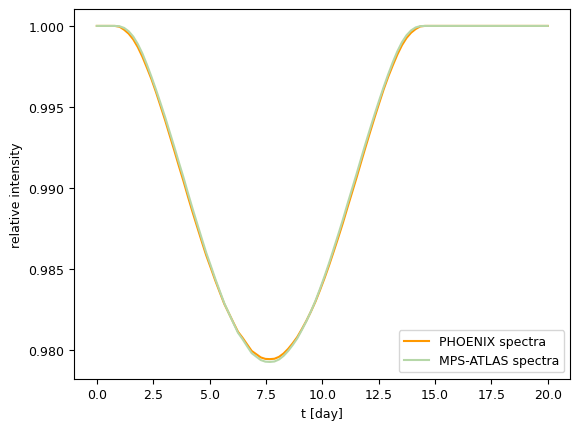

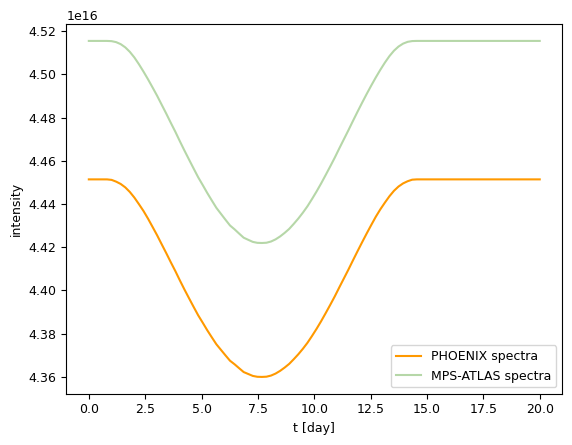

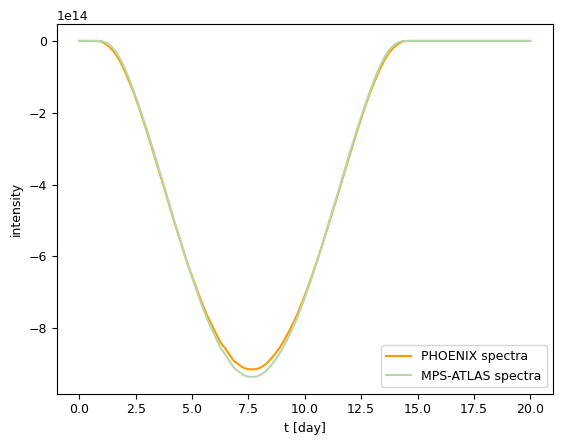

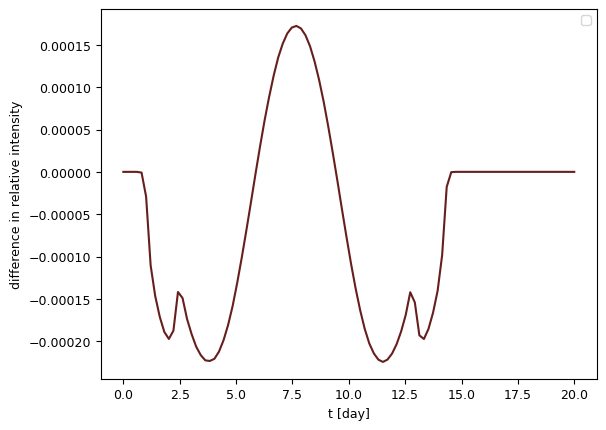

In [8]:
plt.rcParams['font.size'] = 9

plt.plot(t,ss_phoenix_blue.results['lc'], color='#ff9900', label='PHOENIX spectra') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['lc'],color='#b6d7a8', label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/photometry_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(t,ss_phoenix_blue.results['intensity'], color='#ff9900', label='PHOENIX spectra') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['intensity'],color='#b6d7a8', label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/photometry_not_norm_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(t,ss_phoenix_blue.results['intensity'] - ss_phoenix_blue.results['intensity'][0], color='#ff9900', label='PHOENIX spectra') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['intensity'] - ss_mps.results['intensity'][0],color='#b6d7a8', label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/photometry_not_norm_active_only_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(t,ss_phoenix_blue.results['lc']-ss_mps.results['lc'], color="#661F1C") #raw phoenix erg/s/cm^2/cm
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('difference in relative intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/diff_photometry_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

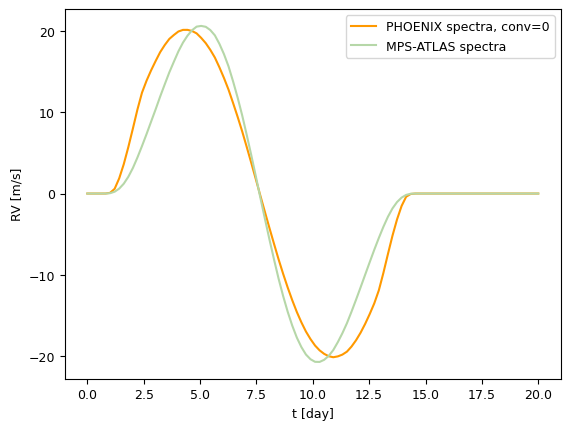

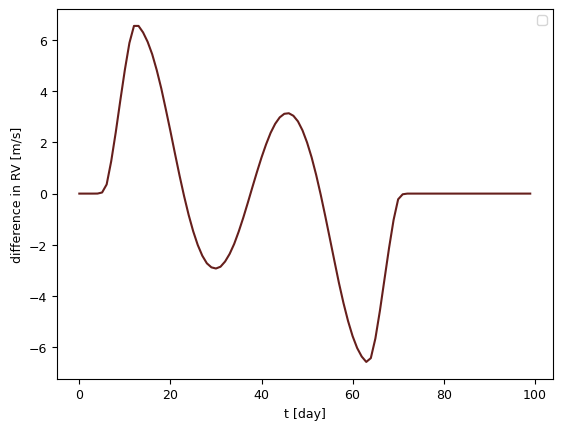

In [10]:
plt.plot(t,ss_phoenix_blue.results['rv'],color='#ff9900', label='PHOENIX spectra, conv=0') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['rv'], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/rv_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(ss_phoenix_blue.results['rv']-ss_mps.results['rv'], color="#661F1C") #raw phoenix erg/s/cm^2/cm
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('difference in RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/mask_specdiff_rv_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

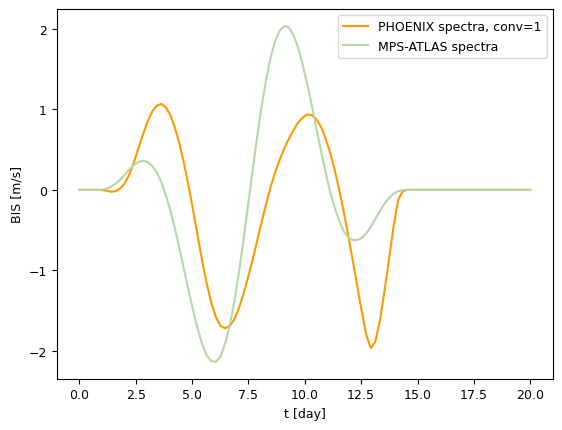

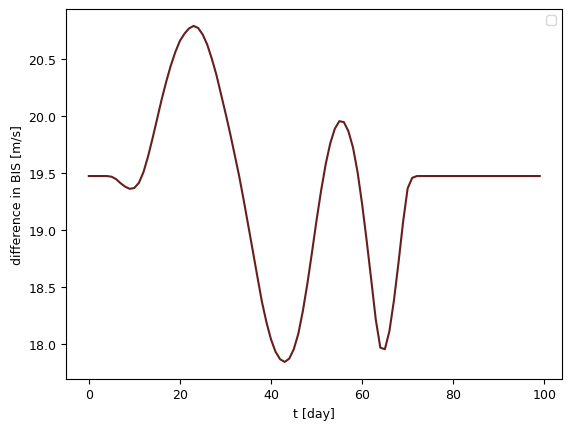

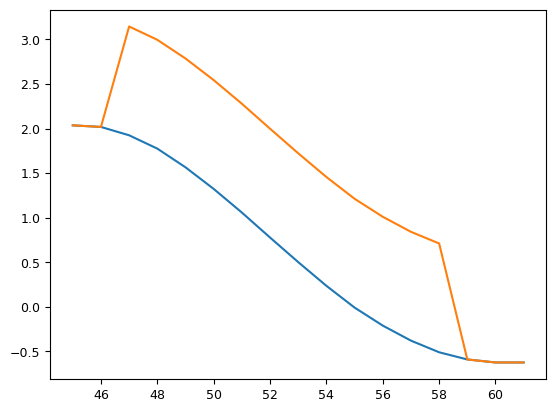

In [10]:
plt.plot(t,ss_phoenix_blue.results['bis'] - ss_phoenix_blue.results['bis'][0],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['bis'] - ss_mps.results['bis'][0], '-', color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('BIS [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/bis_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(ss_phoenix_blue.results['bis']-ss_mps.results['bis'], color="#661F1C") #raw phoenix erg/s/cm^2/cm
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('difference in BIS [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/diff_bis_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()
plt.plot(np.arange(45,62),((ss_mps.results['bis']- ss_mps.results['bis'][0])[45:62]))

plt.plot(np.arange(45,62),((ss_mps.results['bis']- ss_mps.results['bis'][0])[45:62]) + (0.1 + 0.96967621 + 2* 0.07537344) * np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]))

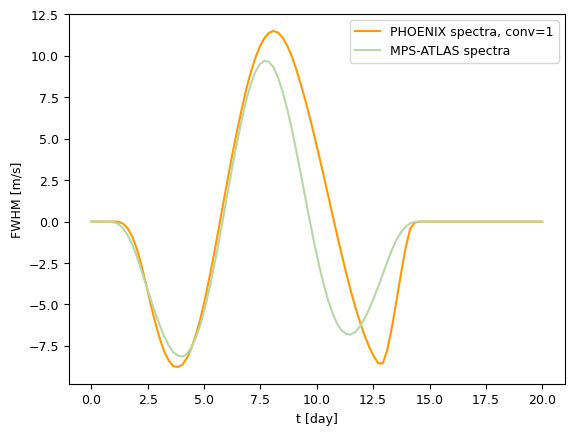

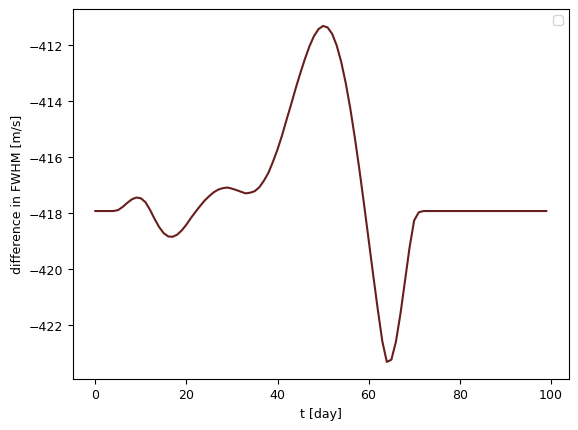

In [11]:
plt.plot(t,ss_phoenix_blue.results['fwhm'] - ss_phoenix_blue.results['fwhm'][0],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['fwhm'] - ss_mps.results['fwhm'][0], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('FWHM [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/fwhm_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

plt.plot(ss_phoenix_blue.results['fwhm']-ss_mps.results['fwhm'], color="#661F1C") #raw phoenix erg/s/cm^2/cm
plt.legend()
plt.xlabel('t [day]')
plt.ylabel('difference in FWHM [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/diff_fwhm_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()

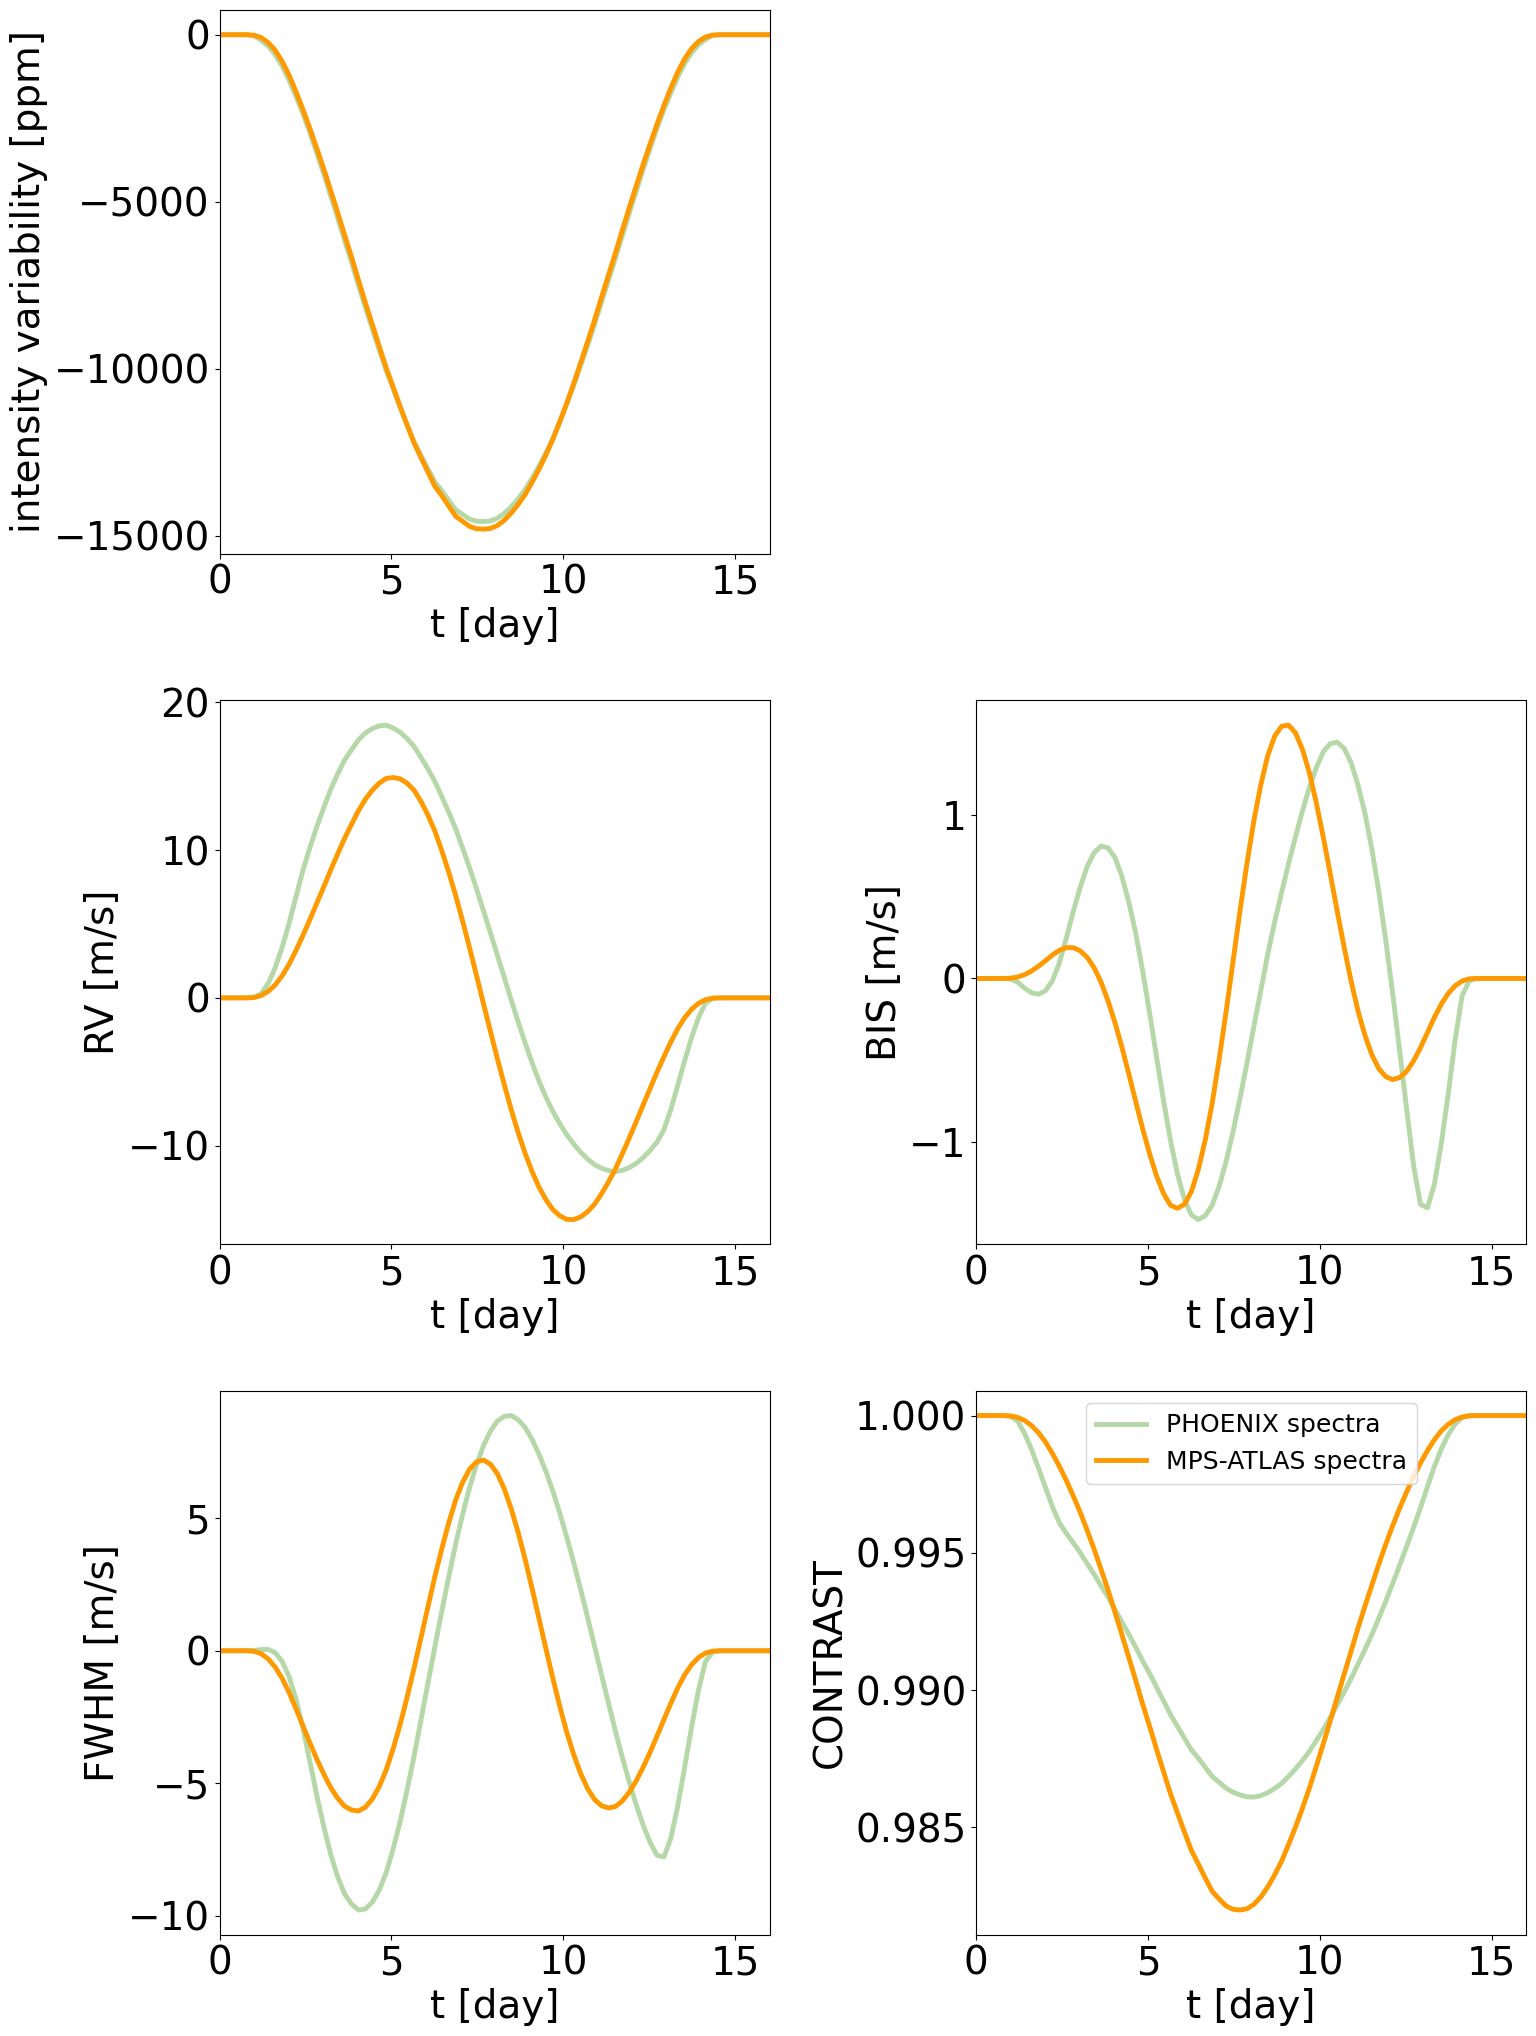

In [12]:
plt.rcParams['font.size'] = 28

plt.rcParams['lines.linewidth'] = 3.5

fig, axs = plt.subplots(3, 2, figsize=(16, 21))


axs[0,0].plot(t, 1e6 * (ss_phoenix_blue.results['lc'] - 1), color='#b6d7a8', label='PHOENIX spectra') #raw phoenix erg/s/cm^2/cm
axs[0,0].plot(t, 1e6 * (ss_mps.results['lc'] - 1),color='#ff9900', label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
# axs[0,0].legend()
axs[0,0].set_xlabel('t [day]')
axs[0,0].set_ylabel('intensity variability [ppm]')
axs[0,0].set_xlim(0,16)

axs[1,0].plot(t,ss_phoenix_blue.results['rv'],color='#b6d7a8', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
axs[1,0].plot(t,ss_mps.results['rv'], color='#ff9900',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

axs[1,0].set_xlabel('t [day]')
axs[1,0].set_ylabel('RV [m/s]')
axs[1,0].set_xlim(0,16)

axs[1,1].plot(t,ss_phoenix_blue.results['bis'] - ss_phoenix_blue.results['bis'][0],color='#b6d7a8', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
axs[1,1].plot(t,ss_mps.results['bis'] - ss_mps.results['bis'][0], '-', color='#ff9900',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

axs[1,1].set_xlabel('t [day]')
axs[1,1].set_ylabel('BIS [m/s]')
axs[1,1].set_xlim(0,16)

axs[2,0].plot(t,ss_phoenix_blue.results['fwhm'] - ss_phoenix_blue.results['fwhm'][0],color='#b6d7a8', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
axs[2,0].plot(t,ss_mps.results['fwhm'] - ss_mps.results['fwhm'][0], color='#ff9900',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

axs[2,0].set_xlabel('t [day]')
axs[2,0].set_ylabel('FWHM [m/s]')
axs[2,0].set_xlim(0,16)

axs[2,1].plot(t,ss_phoenix_blue.results['contrast'] ,color='#b6d7a8', label='PHOENIX spectra') #raw phoenix erg/s/cm^2/cm
axs[2,1].plot(t,ss_mps.results['contrast'], color='#ff9900',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

axs[2,1].set_xlabel('t [day]')
axs[2,1].set_ylabel('CONTRAST')
axs[2,1].set_xlim(0,16)
axs[2,1].legend(fontsize=18)


fig.delaxes(axs[0,1])  

plt.tight_layout()

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/diffs_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300, transparent=True)


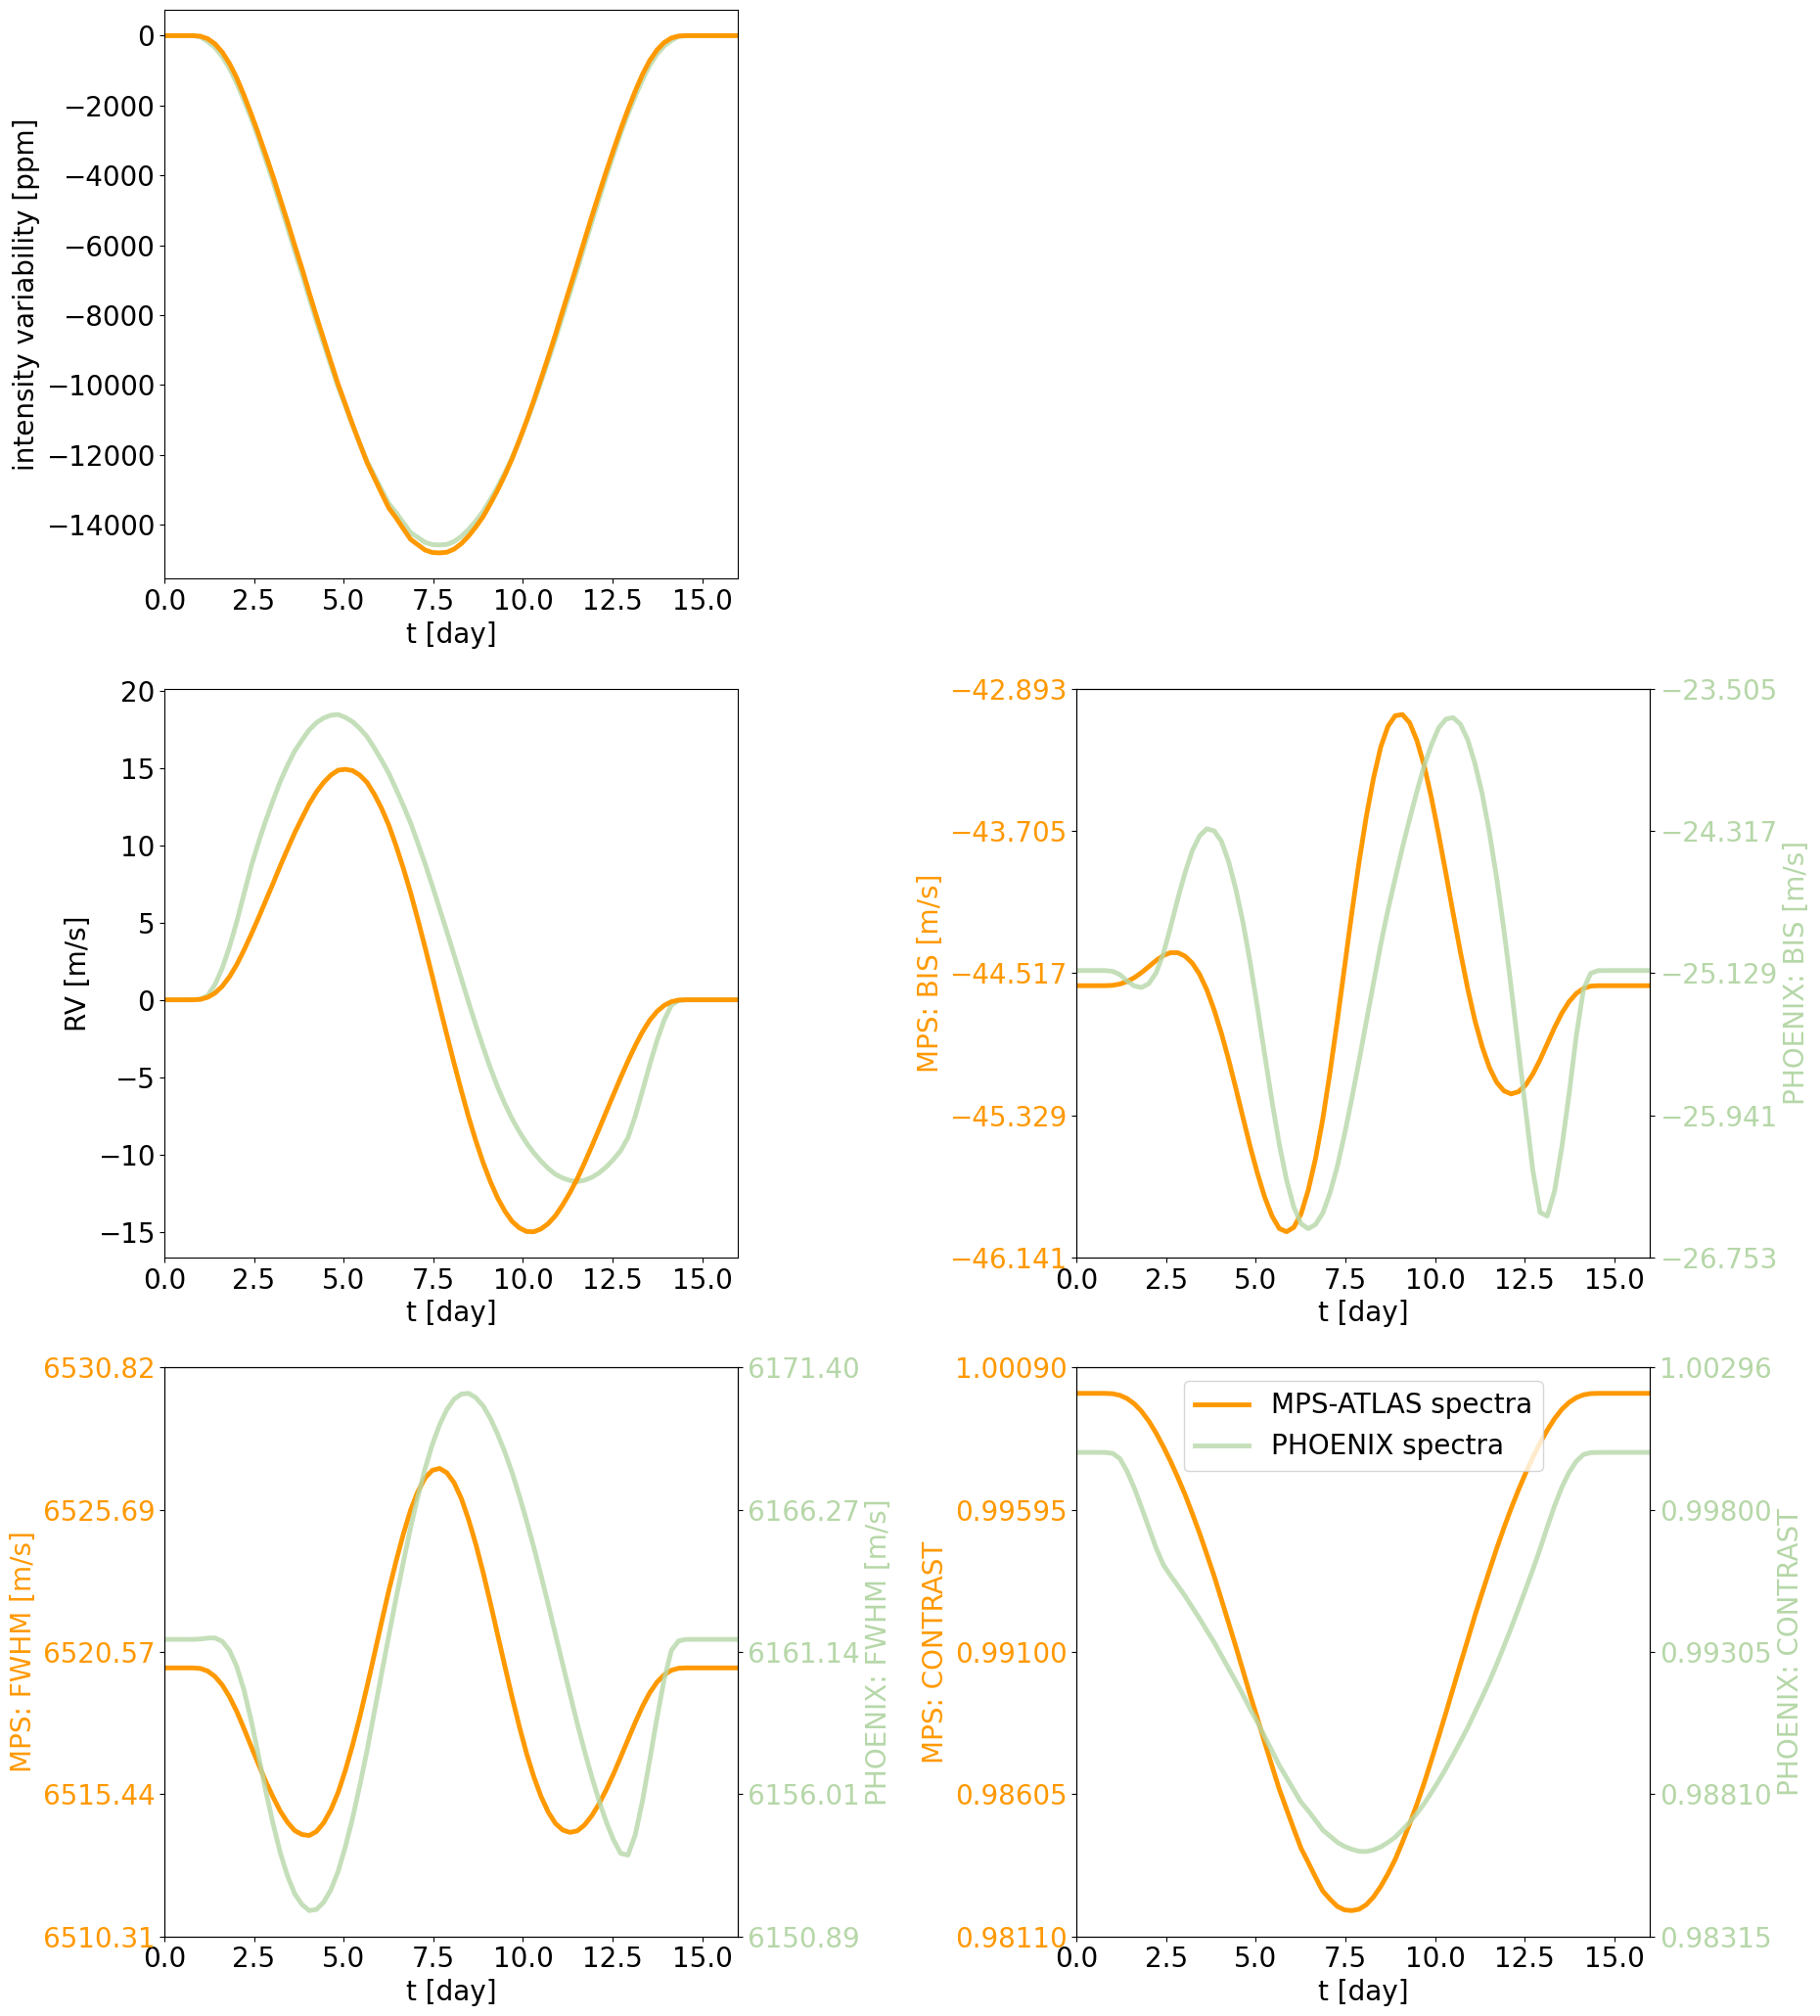

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 20
plt.rcParams['lines.linewidth'] = 3.5

fig, axs = plt.subplots(3, 2, figsize=(19, 21))

def match_yaxis_range_and_ticks(ax1, ax2, data1, data2, num_ticks=5):
    min1, max1 = np.min(data1), np.max(data1)
    min2, max2 = np.min(data2), np.max(data2)

    span1 = max1 - min1
    span2 = max2 - min2
    full_span = max(span1, span2)

    pad = 0.05 * full_span
    full_span += 2 * pad

    center1 = (max1 + min1) / 2
    center2 = (max2 + min2) / 2

    ax1.set_ylim(center1 - full_span / 2, center1 + full_span / 2)
    ax2.set_ylim(center2 - full_span / 2, center2 + full_span / 2)

    ticks = np.linspace(-full_span/2, full_span/2, num_ticks)
    ax1.set_yticks(center1 + ticks)
    ax2.set_yticks(center2 + ticks)

# LC
axs[0,0].plot(t, 1e6 * (ss_phoenix_blue.results['lc'] - 1), color='#b6d7a8', label='PHOENIX spectra', alpha=0.8) #raw phoenix erg/s/cm^2/cm
axs[0,0].plot(t, 1e6 * (ss_mps.results['lc'] - 1),color='#ff9900', label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
# axs[0,0].legend()
axs[0,0].set_xlabel('t [day]')
axs[0,0].set_ylabel('intensity variability [ppm]')
axs[0,0].set_xlim(0,16)

# RV
axs[1,0].plot(t,ss_phoenix_blue.results['rv'],color='#b6d7a8', label='PHOENIX spectra, conv=1', alpha=0.8) #raw phoenix erg/s/cm^2/cm
axs[1,0].plot(t,ss_mps.results['rv'], color='#ff9900',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

axs[1,0].set_xlabel('t [day]')
axs[1,0].set_ylabel('RV [m/s]')
axs[1,0].set_xlim(0,16)

# BIS
ax = axs[1, 1]
axb = ax.twinx()
data_mps = ss_mps.results['bis'] 
data_phx = ss_phoenix_blue.results['bis'] 

ax.plot(t, data_mps, color='#ff9900', label='MPS-ATLAS spectra')
axb.plot(t, data_phx, color='#b6d7a8', label='PHOENIX spectra', alpha=0.8)

ax.set_xlabel('t [day]')
ax.set_ylabel('MPS: BIS [m/s]', color='#ff9900')
axb.set_ylabel('PHOENIX: BIS [m/s]', color='#b6d7a8')
ax.tick_params(axis='y', labelcolor='#ff9900')
axb.tick_params(axis='y', labelcolor='#b6d7a8')
ax.set_xlim(0, 16)

match_yaxis_range_and_ticks(ax, axb, data_mps, data_phx)

# FWHM
ax = axs[2, 0]
axb = ax.twinx()
data_mps = ss_mps.results['fwhm'] 
data_phx = ss_phoenix_blue.results['fwhm'] 

ax.plot(t, data_mps, color='#ff9900', label='MPS-ATLAS spectra')
axb.plot(t, data_phx, color='#b6d7a8', label='PHOENIX spectra', alpha=0.8)

ax.set_xlabel('t [day]')
ax.set_ylabel('MPS: FWHM [m/s]', color='#ff9900')
axb.set_ylabel('PHOENIX: FWHM [m/s]', color='#b6d7a8')
ax.tick_params(axis='y', labelcolor='#ff9900')
axb.tick_params(axis='y', labelcolor='#b6d7a8')
ax.set_xlim(0, 16)

match_yaxis_range_and_ticks(ax, axb, data_mps, data_phx)

# CONTRAST
ax = axs[2, 1]
axb = ax.twinx()
data_mps = ss_mps.results['contrast'] 
data_phx = ss_phoenix_blue.results['contrast'] 

ax.plot(t, data_mps, color='#ff9900', label='MPS-ATLAS spectra')
axb.plot(t, data_phx, color='#b6d7a8', label='PHOENIX spectra', alpha=0.8)

ax.set_xlabel('t [day]')
ax.set_ylabel('MPS: CONTRAST', color='#ff9900')
axb.set_ylabel('PHOENIX: CONTRAST', color='#b6d7a8')
ax.tick_params(axis='y', labelcolor='#ff9900')
axb.tick_params(axis='y', labelcolor='#b6d7a8')
ax.set_xlim(0, 16)

match_yaxis_range_and_ticks(ax, axb, data_mps, data_phx)

# Legend on last subplot
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = axb.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Remove empty subplot
fig.delaxes(axs[0, 1])

plt.tight_layout()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/diffs_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300, transparent=True)



In [14]:
0.1 + 0.96967621 + 2* 0.0753734

1.2204230100000002

In [15]:
def gaussian2(x, amplitude, mean, stddev,C):
    return C + amplitude * np.exp(-(x-mean)**2/(2*stddev**2))

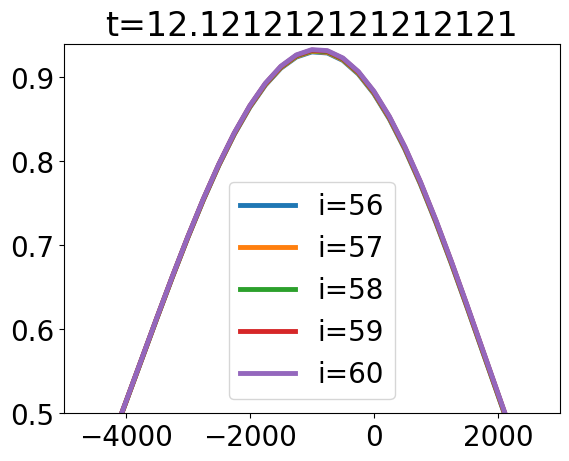

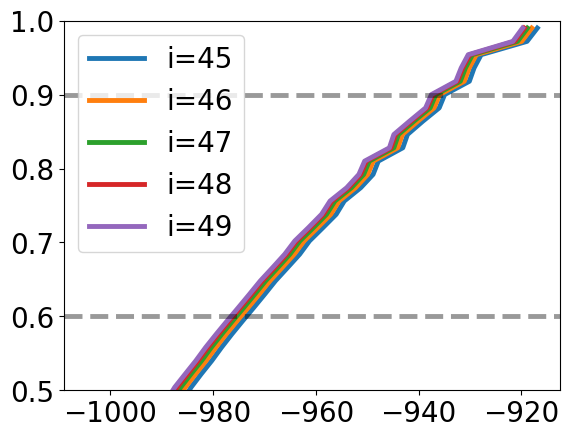

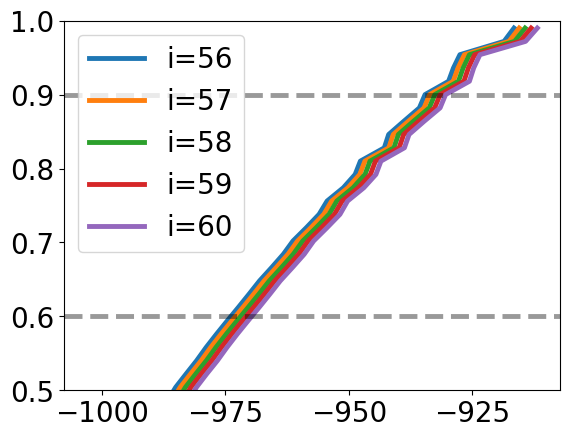

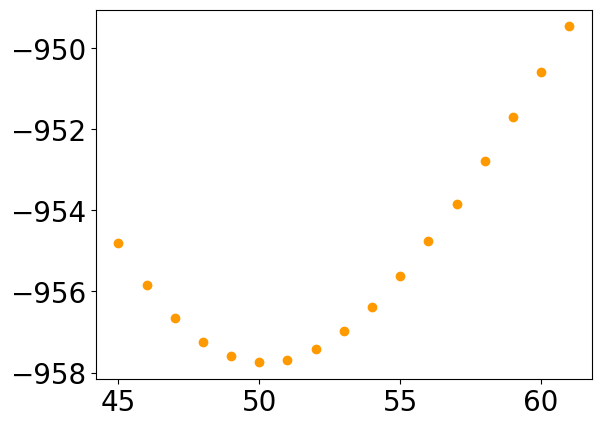

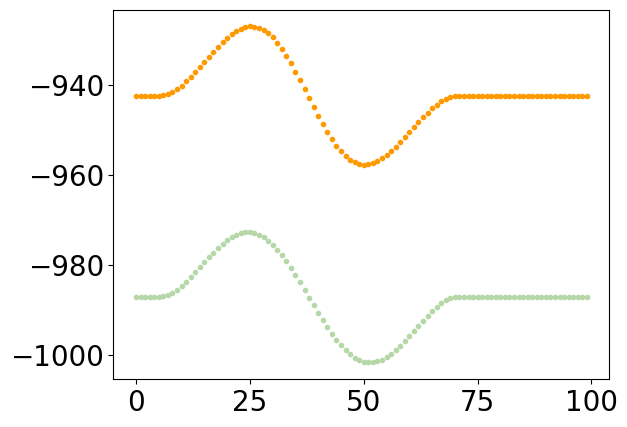

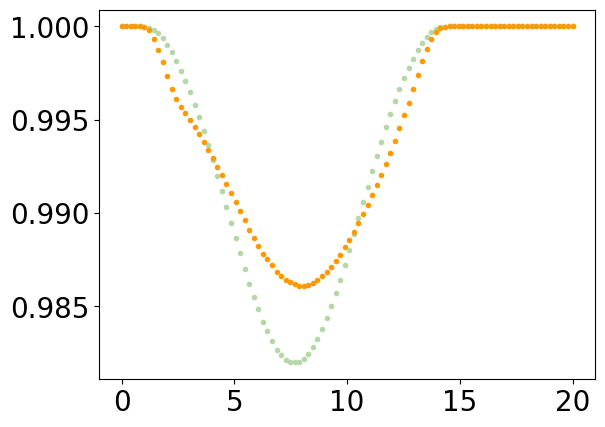

In [16]:
for i in np.arange(56,61):

    # plt.plot(ss_phoenix_blue.results['CCF'][0],ss_phoenix_blue.results['CCF'][i+1],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
    plt.plot(ss_mps.results['CCF'][0],ss_mps.results['CCF'][i+1], label='i={}'.format(i)) #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
    plt.title('t={}'.format(t[i]))
plt.ylim(0.5,0.94)
plt.xlim(-5000,3000)
plt.legend()
plt.show()

# for i in np.arange(45,62):

#     plt.plot(ss_phoenix_blue.results['CCF'][0],ss_phoenix_blue.results['CCF'][i+1], label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
#     # plt.plot(ss_mps.results['CCF'][0],ss_mps.results['CCF'][i+1], label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}
#     plt.title('t={}'.format(t[i]))

# plt.show()

# for i in range(len(t)):
#     stddev = ss_mps.results['fwhm'][i] / 2*np.sqrt(2*np.log(2))
#     plt.plot(ss_mps.results['CCF'][0], gaussian2(ss_mps.results['CCF'][0], ss_mps.results['contrast'][i], ss_mps.results['rv'][i], stddev, 0))
# plt.show()

# for i in range(len(t)):
#     stddev = ss_phoenix_blue.results['fwhm'][i] / 2*np.sqrt(2*np.log(2))
#     plt.plot(ss_phoenix_blue.results['CCF'][0], gaussian2(ss_phoenix_blue.results['CCF'][0], ss_phoenix_blue.results['contrast'][i], ss_phoenix_blue.results['rv'][i], stddev, 0))
#
#  # plt.show()
for i in np.arange(45,50):
    plt.plot(np.transpose(ss_mps.results['raw_xbis'][i]), np.transpose(ss_mps.results['raw_ybis'][i]), label='i={}'.format(i))
plt.ylim(0.5,1)
plt.axhline(0.6, linestyle='--', color='k', alpha =0.4)
plt.axhline(0.9, linestyle='--', color='k',  alpha=0.4)
plt.legend()
plt.show()

for i in np.arange(56,61):
    plt.plot(np.transpose(ss_mps.results['raw_xbis'][i]), np.transpose(ss_mps.results['raw_ybis'][i]), label='i={}'.format(i))
plt.ylim(0.5,1)
plt.axhline(0.6, linestyle='--', color='k', alpha =0.4)
plt.axhline(0.9, linestyle='--', color='k',  alpha=0.4)
plt.legend()
plt.show()

for i in np.arange(45,62):
    # plt.plot(i, np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.1) & np.array(ss_mps.results['raw_ybis'][i]<=0.4)]), '.', color='#b6d7a8')
    plt.plot(i, np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.6) & np.array(ss_mps.results['raw_ybis'][i]<=0.9)]), 'o',color='#ff9900')

plt.show()

for i in range(len(t)):
    plt.plot(i, np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.1) & np.array(ss_mps.results['raw_ybis'][i]<=0.4)]), '.', color='#b6d7a8')
    plt.plot(i, np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.6) & np.array(ss_mps.results['raw_ybis'][i]<=0.9)]), '.',color='#ff9900')


plt.show()
# for i in np.arange(45,48):
#     plt.plot(np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.1) & np.array(ss_mps.results['raw_ybis'][i]<=0.4)]), np.mean(ss_mps.results['raw_xbis'][i][np.array(ss_mps.results['raw_ybis'][i]>=0.6) & np.array(ss_mps.results['raw_ybis'][i]<=0.9)]), 'og')
# # plt.plot(np.transpose(ss_phoenix_blue.results['raw_xbis']), np.transpose(ss_phoenix_blue.results['raw_ybis']))
# plt.show()

for i in range(len(t)):
    plt.plot(t[i], ss_mps.results['contrast'][i], '.', color='#b6d7a8')
    plt.plot(t[i], ss_phoenix_blue.results['contrast'][i], '.',color='#ff9900')
plt.show()



In [17]:
def speed_bisector_nb(rv,ccf,integrated_bis):
    ''' Fit the bisector of the CCF with a 5th deg polynomial
    '''
    idxmax=ccf.argmax()
    maxccf=ccf[idxmax]
    maxrv=rv[idxmax]

    xnew = rv
    ynew = ccf


    cutleft=0
    cutright=len(ynew)-1
    # if not integrated_bis: #cut the CCF at the minimum of the wings only for reference CCF, if not there are errors.
    for i in range(len(ynew)):
        if xnew[i]>maxrv:
            if ynew[i]>ynew[i-1] and ynew[i]<0.8*maxccf:
                cutright=i
                break

    for i in range(len(ynew)):
        if xnew[-1-i]<maxrv:
            if ynew[-1-i]>ynew[-i] and ynew[i]<0.8*maxccf:
                cutleft=len(ynew)-i
                break

    xnew=xnew[cutleft:cutright]
    ynew=ynew[cutleft:cutright]
    
    minright=np.min(ynew[xnew>maxrv])
    minleft=np.min(ynew[xnew<maxrv])
    minccf=np.max(np.array([minright,minleft]))
    
    if integrated_bis:
        ybis=np.linspace(minccf+0.1*(maxccf-minccf),0.99*maxccf,50) #from 5% to maximum
    else:
        ybis=np.linspace(minccf+0.1*(maxccf-minccf),0.999*maxccf,50) #from 5% to maximum
    xbis=np.zeros(len(ybis))

    rv1_list = []
    rv2_list = []
    for i in range(len(ybis)):    
        for j in range(len(ynew)-1):
            if ynew[j]<ybis[i] and ynew[j+1]>ybis[i] and xnew[j]<maxrv:
                rv1=xnew[j]+(xnew[j+1]-xnew[j])*(ybis[i]-ynew[j])/(ynew[j+1]-ynew[j])
            if ynew[j]>ybis[i] and ynew[j+1]<ybis[i] and xnew[j+1]>maxrv:
                rv2=xnew[j]+(xnew[j+1]-xnew[j])*(ybis[i]-ynew[j])/(ynew[j+1]-ynew[j])
        xbis[i]=(rv1+rv2)/2.0 #bisector
        rv1_list.append(rv1)
        rv2_list.append(rv2)

    # xbis[-1]=maxrv #at the top should be max RV

    return cutleft,cutright,xbis,ybis, rv1_list, rv2_list

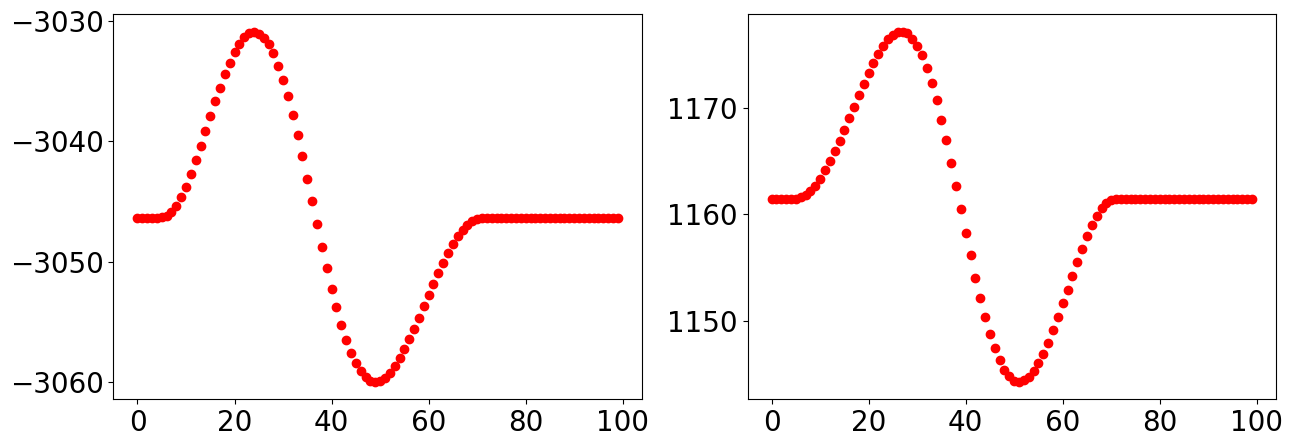

In [18]:
fig, axs = plt.subplots(1,2, figsize= (15, 5))
for i in np.arange(0, 100):
    # print(i)
    cutleft,cutright,xbis,ybis, rv1, rv2 = speed_bisector_nb(ss_mps.results['CCF'][0],ss_mps.results['CCF'][i+1] / ss_mps.results['CCF'][i+1].max(),integrated_bis=True)
    # plt.plot(i, np.mean(xbis[np.array(ybis<=0.9) & np.array(ybis>=0.6)]), 'ok')
    # plt.plot(rv1, ybis, 'xr')
    # plt.plot(rv2, ybis, 'xg')
    # plt.plot(xbis, ybis)
    # plt.ylim(0.55, 0.95)
    # plt.xlim(-4100,2200)
    # plt.axhline(0.6, linestyle='--', color='k', alpha=0.4)
    # plt.axhline(0.9, linestyle='--', color='k', alpha=0.4)

    # plt.show()

    axs[0].plot(i, np.mean(np.array(rv1)[np.array(ybis<=0.9) & np.array(ybis>=0.6)]), 'or')
    axs[1].plot(i, np.mean(np.array(rv2)[np.array(ybis<=0.9) & np.array(ybis>=0.6)]), 'or')




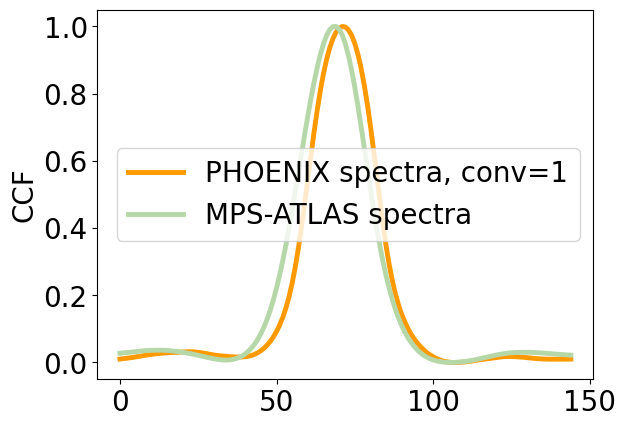

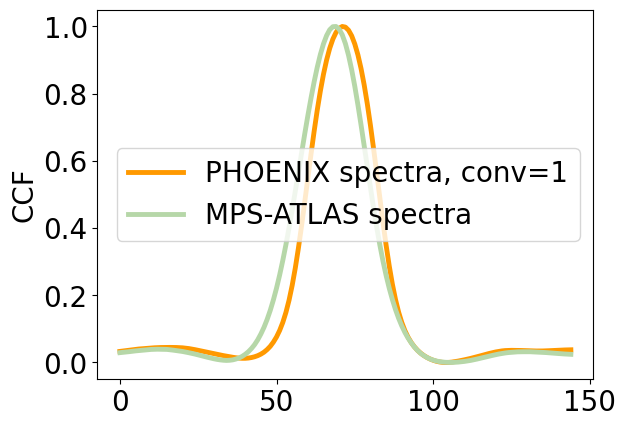

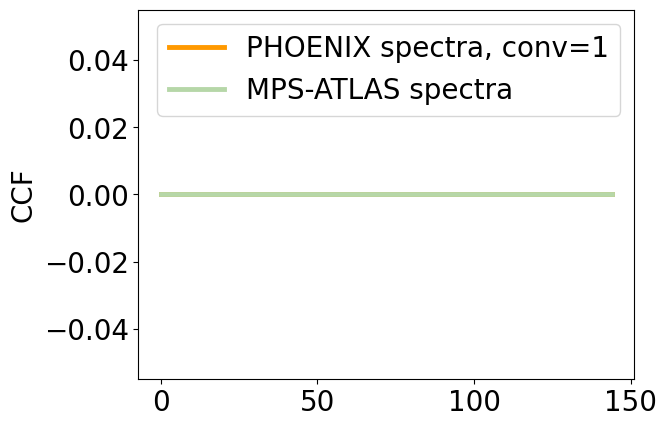

In [19]:
plt.plot(ss_phoenix_blue.results['ccf_sp'],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(ss_mps.results['ccf_sp'], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('')
plt.ylabel('CCF')
# plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/fwhm_type_{}.png'.format(type_list), dpi=300)
plt.show()

plt.plot(ss_phoenix_blue.results['ccf_ph'],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(ss_mps.results['ccf_ph'], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('')
plt.ylabel('CCF')
# plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/fwhm_type_{}.png'.format(type_list), dpi=300)
plt.show()

plt.plot(ss_phoenix_blue.results['ccf_fc'],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(ss_mps.results['ccf_fc'], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('')
plt.ylabel('CCF')
# plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/fwhm_type_{}.png'.format(type_list), dpi=300)
plt.show()



In [20]:
plt.rcParams['font.size'] = 18

def update(frame, ax, fig, lags, scalar_map, t, rv_sim, CCF_p, RV, BIS, raw_xbis, raw_ybis, lc, path_grid):
    ax[1,0].cla()
    ax[1,1].cla()
    lag = lags[frame]

    color_val = scalar_map.to_rgba(rv_sim[lag])
    
    #plot RVs
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,2].plot(t[i],rv_sim[i], color=color_val,marker='.', markersize=12)
    ax[0,2].set_xlim(t.min(),t.max())
    ax[0,2].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[0,2].plot(t[:lag],rv_sim[:lag],color='gray', alpha=0.2, linewidth= 1)
    
    #plot CCF
    ax[1,0].plot(RV[:],CCF_p[lag], color=color_val,alpha=0.9)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,0].plot(RV[:],CCF_p[i], color=color_val,alpha=0.1)


    #plot BIS (mean diff)
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,2].plot(t[i],BIS[i], color=color_val,marker='.', linestyle='None', markersize=12)
    ax[1,2].plot(t[:lag],BIS[:lag],color='gray', alpha=0.2, linewidth= 1)

    #plot BIS
    ax[1,1].plot(raw_xbis[lag] - (np.max(raw_xbis[lag]) + np.min(raw_xbis[lag])) / 2,raw_ybis[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,1].plot(raw_xbis[i] - (np.max(raw_xbis[i]) + np.min(raw_xbis[i])) / 2,raw_ybis[i], color=color_val,alpha=0.1)
    ax[1,1].set_xlim(-50, 50)


    #plot flux intensity
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,1].plot(t[i],lc[i], color=color_val,marker='.', markersize=12)
    ax[0,1].set_xlim(t.min(),t.max())
    ax[0,1].plot(t[:lag],lc[:lag],color='gray', alpha=0.2, linewidth= 1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))

    
    color_dict = { 0:'#CA6702', 1:'#9B2226', 2:'#EE9B00', 3:'#0A9396'}
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    vec_grid=np.load(path_grid+'vec_gridt{:.4f}.npy'.format(t[lag]))
    typ=np.load(path_grid+'typt{:.4f}.npy'.format(t[lag]))
    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[0,0].scatter(vec_grid[:,1],vec_grid[:,2], color=[ color_dict[np.argmax(i)] for i in typ ],s=50, alpha=0.8)
    #ax[0,0].plot(x,h,'k')
    
    ax[1,0].set_ylabel('CCF power')
    ax[1,0].set_xlabel('RV (m/s)')
    ax[1,0].set_ylim(CCF_p.min()-np.abs(CCF_p.min())/10,CCF_p.max()+np.abs(CCF_p.max())/10)
    ax[0,2].set_ylabel('RV (m/s)')
    ax[0,2].set_xlabel('t (d)')
    ax[0,1].set_ylabel('f')
    ax[0,1].set_xlabel('t (d)')
    ax[1,2].set_ylabel('BIS span')
    ax[1,2].set_xlabel('t (D)')
    ax[1,1].set_xlabel('RV (m/S)')
    ax[1,1].set_ylabel('BIS')

    ax[0,0].locator_params(axis='y',nbins=5)
    ax[1,0].locator_params(axis='x',nbins=5)

    ax[0,1].ticklabel_format(axis='both', style='sci')
    ax[1,0].ticklabel_format(axis='both', style='sci')

    ax[0,0].tick_params(grid_alpha=0.7)
    ax[0,1].tick_params(grid_alpha=0.7)
    ax[0,2].tick_params(grid_alpha=0.7)
    ax[1,0].tick_params(grid_alpha=0.7)
    ax[1,1].tick_params(grid_alpha=0.7)
    ax[1,2].tick_params(grid_alpha=0.7)

    fig.tight_layout()


def retrieve_observable(ss, t, pathdata, path_grid, output):
    """
    Load and save the #TODO

    Params:
            -ss: starsim object
            -t: timeframe
    
    """

    rv_sim=ss.results['rv']
    CCF=ss.results['CCF'][1:]
    RV=ss.results['CCF'][0]
    lc = ss.results['lc']
    BIS = ss.results['bis']
    raw_xbis = ss.results['raw_xbis']
    raw_ybis = ss.results['raw_ybis']



    '''
    Generate an animated GIF
    '''

    CCF_p =CCF[:] -np.mean(CCF,axis=0)

    lags = np.arange(len(t))


    # Normalize the continuous variable to map it to the range [0, 1] for the colormap
    norm = Normalize(vmin=-np.max((np.abs(rv_sim))), vmax=np.max((np.abs(rv_sim))))
    List = ['#104f5c', '#2c6570', '#477b83', '#639295', '#84a8a5', '#c7b7a0', '#e49a77', '#e5845f', '#de714d', '#d3603e', '#c65031']

    colormap = get_continuous_cmap(List)
    scalar_map = ScalarMappable(norm=norm, cmap=colormap)

    fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30/1.5 + 2, 20/1.5))

    # Create an animation
    ani = FuncAnimation(fig, partial(update, ax=ax, fig=fig, lags=lags, scalar_map=scalar_map, t=t, rv_sim=rv_sim, CCF_p=CCF_p, RV=RV, BIS=BIS, raw_xbis=raw_xbis, raw_ybis=raw_ybis, lc=lc, path_grid=path_grid), frames=len(lags), repeat=False)

    # Save the animation as a video
    writer = FFMpegWriter(fps=3, metadata=dict(artist='Me'), bitrate=2400)

    
    ani.save(pathdata+output+'.gif', writer=writer)

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '2200x1332', '-pix_fmt', 'rgba', '-framerate', '3', '-loglevel', 'error', '-i', 'pipe:', '-filter_complex', 'split [a][b];[a] palettegen [p];[b][p] paletteuse', '-b', '2400k', '-metadata', 'artist=Me', '-y', '/home/sophie-stucki/Documents/starsim_simulations/nina_spec/sp_mps.gif']' returned non-zero exit status 255.

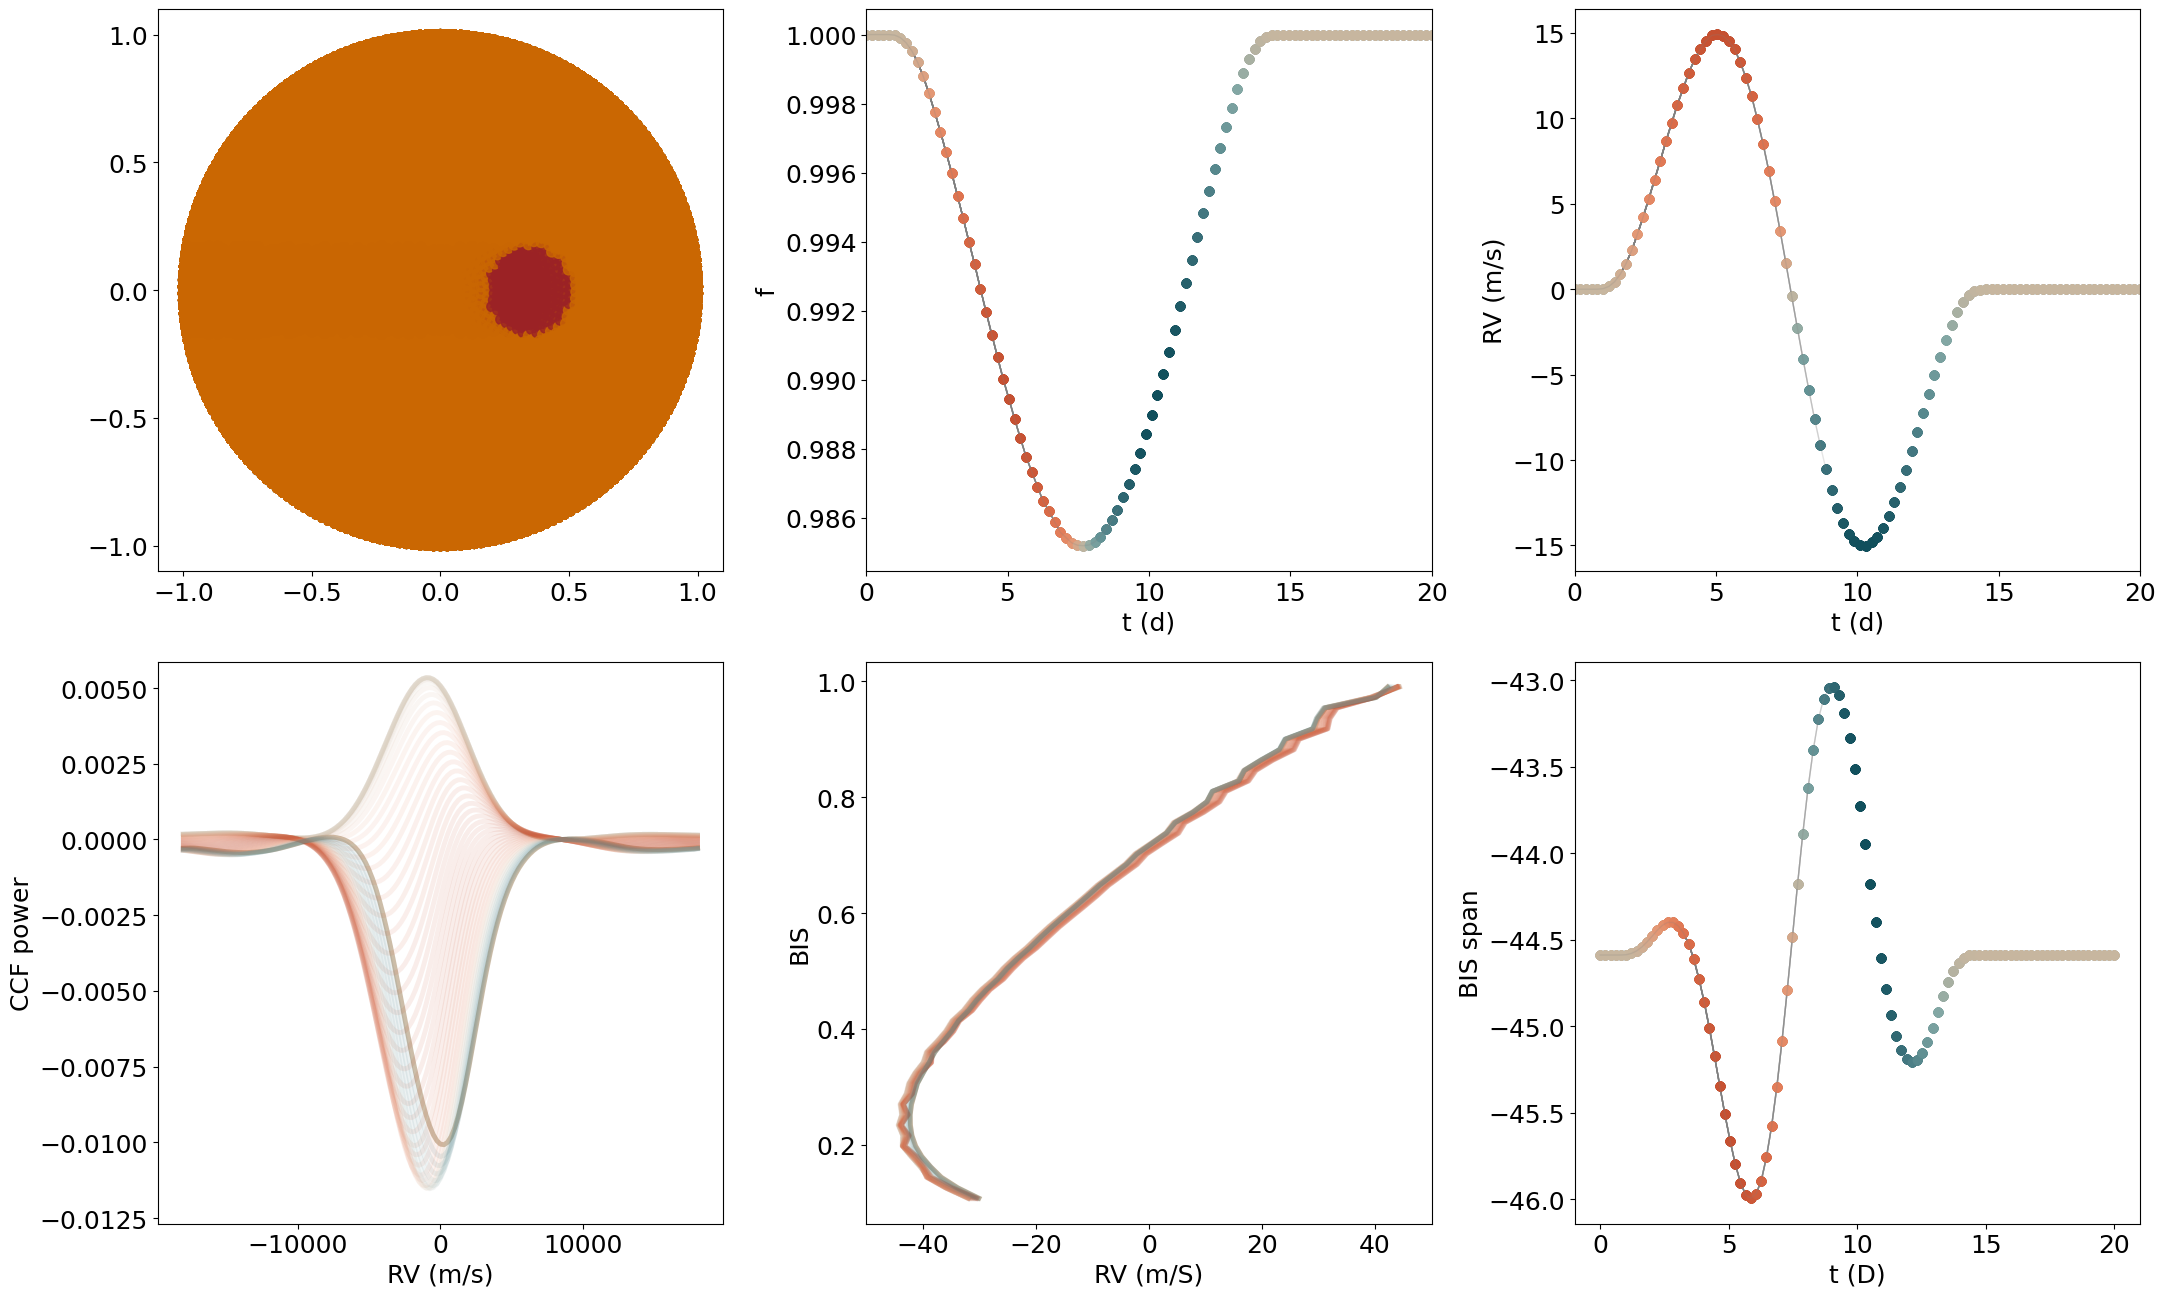

In [21]:
output = 'sp_mps'
retrieve_observable(ss_mps, t, pathdata, path_grid, output)

In [ ]:
# low res
name_mps = 'av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid'
name_mps_fc = 'av_solar_faculae_200G_10_mu_angles_PHOENIX_low_res_specint_grid'

low_mps_cleaned = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps+'_cleaned.npy', allow_pickle=True).item()
low_mps_fc_cleaned = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps_fc+'_cleaned.npy', allow_pickle=True).item()

low_mps_ph = ss_mps.results['flnp_lc']
low_phoenix = ss_mps.results['flnp_lc_ph']
low_phoenix_sp = ss_mps.results['flns_lc']
wav = ss_mps.results['wvp_lc']

KeyError: 'flnp_lc_ph'

In [ ]:
r_sun = 696.340 # km
d = 1.496e+11 #m 

(1e5 * r_sun)**2 / d**2

2.1666037937172926e-07

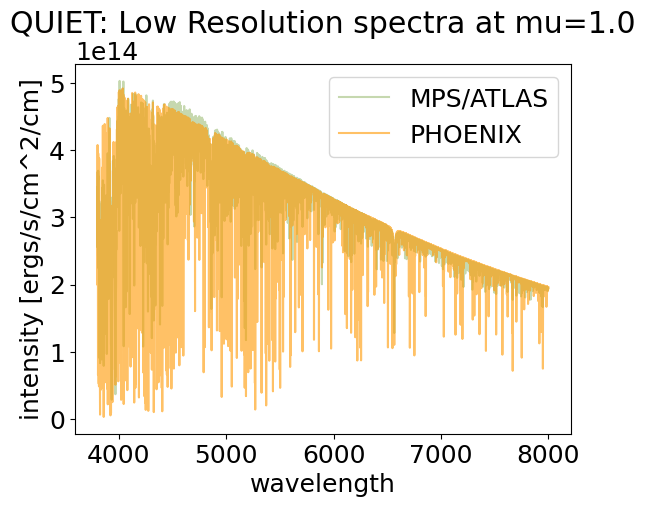

1.2894499913445166e+18
1.2554958132164e+18
3.3954178128116736e+16


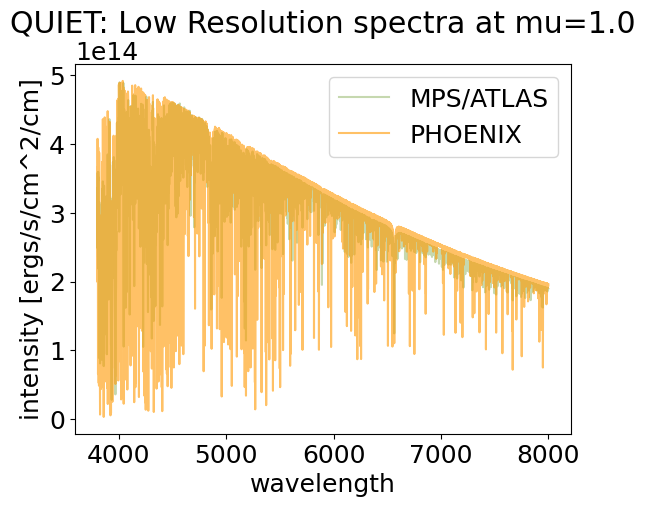

In [ ]:
plt.plot(wav, low_mps_ph[0], color="#C6D8AF", label='MPS/ATLAS', alpha=1) # erg/s/cm2/A
plt.plot(wav, low_phoenix[0] , color='#ff9900', label='PHOENIX', alpha = 0.6) # erg/s/cm2/cm
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('QUIET: Low Resolution spectra at mu=1.0')
plt.legend()
plt.show()

print(np.sum(low_mps_ph[0]))
print(np.sum(low_phoenix[0]))
print(np.sum(low_mps_ph[0]) - np.sum(low_phoenix[0]))


plt.plot(wav, low_mps_ph[0] / np.sum(low_mps_ph[0]) * np.sum(low_phoenix[0]), color="#C6D8AF", label='MPS/ATLAS', alpha=1) # erg/s/cm2/A
plt.plot(wav, low_phoenix[0] , color='#ff9900', label='PHOENIX', alpha = 0.6) # erg/s/cm2/cm
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('QUIET: Low Resolution spectra at mu=1.0')
plt.legend()
plt.show()

In [ ]:
def normalize_spectra_nb(bins,wavelength,flux):

    x_bin=np.zeros(len(bins)-1)
    y_bin=np.zeros(len(bins)-1)
    for i in range(len(bins)-1):
        idxup = wavelength>bins[i]
        idxdown= wavelength<bins[i+1]
        idx=idxup & idxdown
        y_bin[i]=flux[idx].max()
        x_bin[i]=wavelength[idx][np.argmax(flux[idx])]
    #divide by 6th deg polynomial

    return x_bin, y_bin

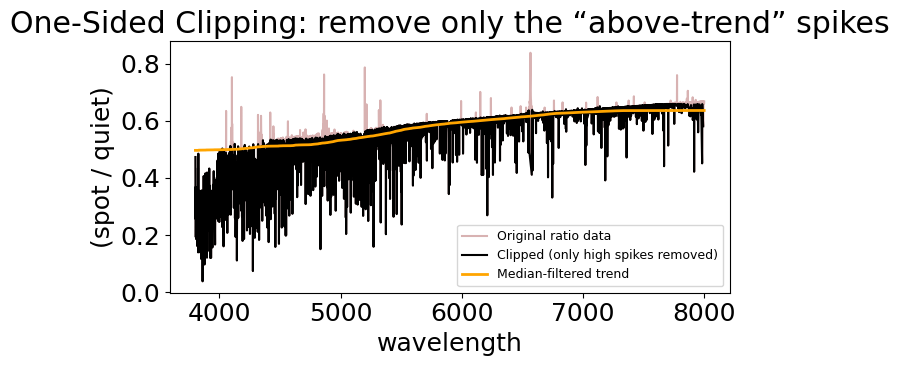

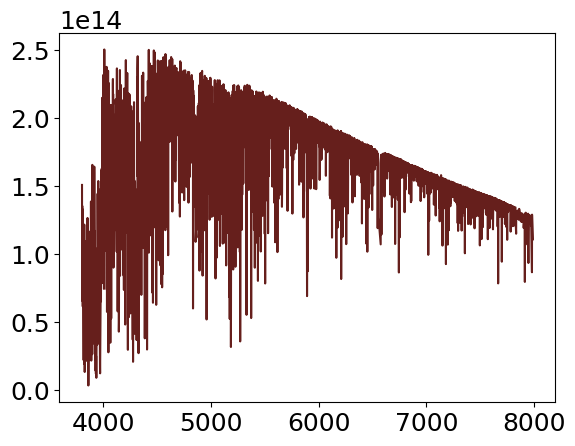

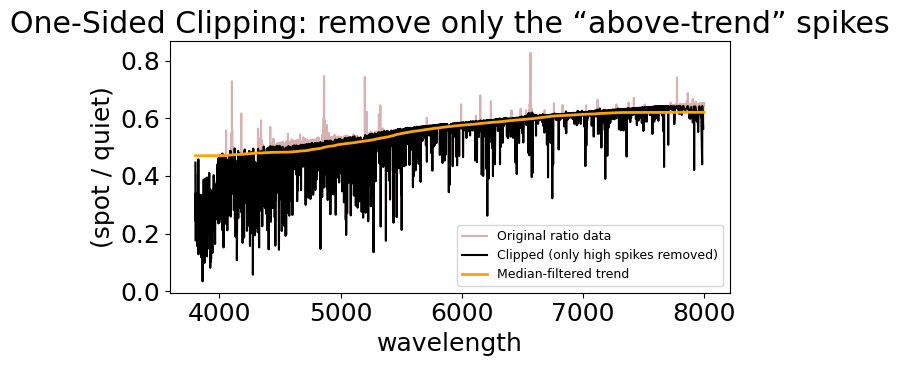

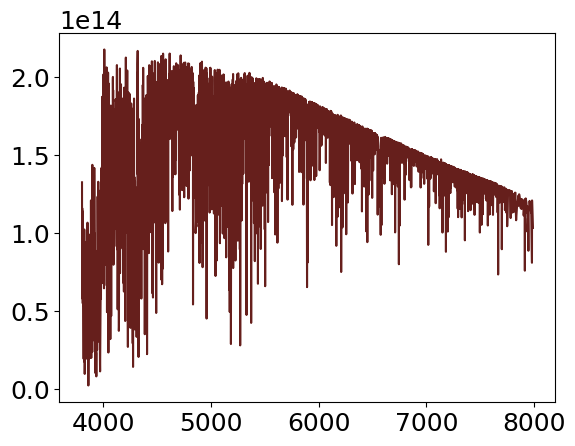

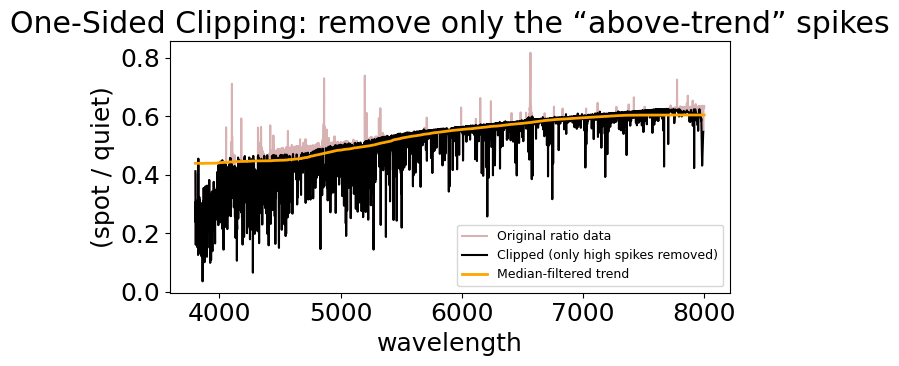

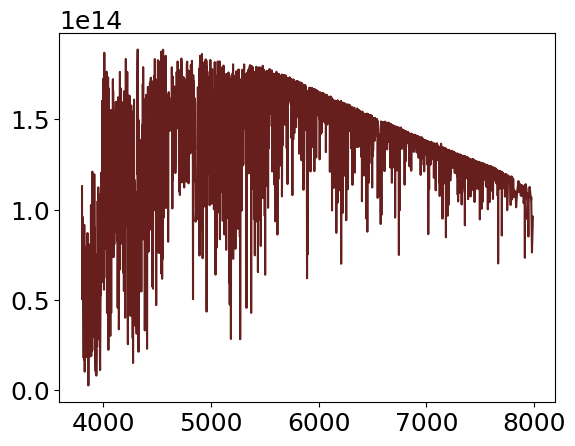

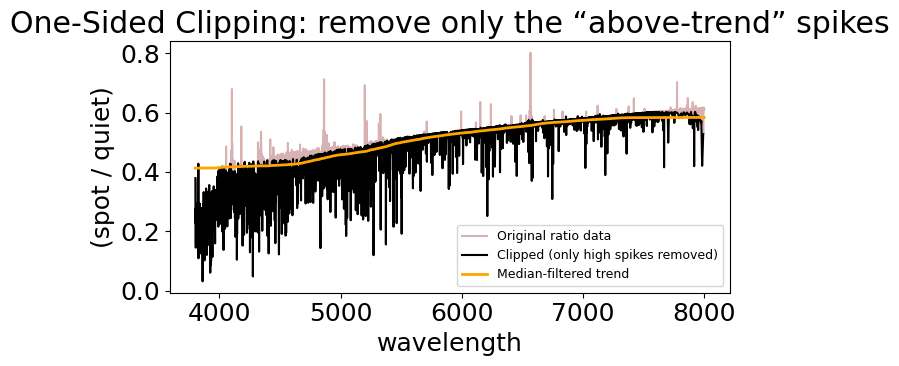

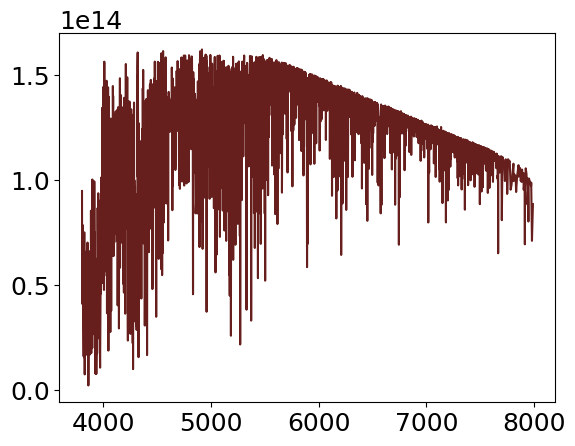

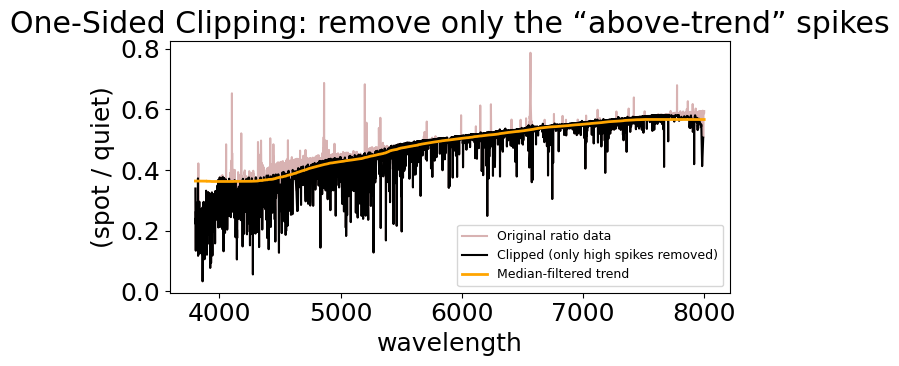

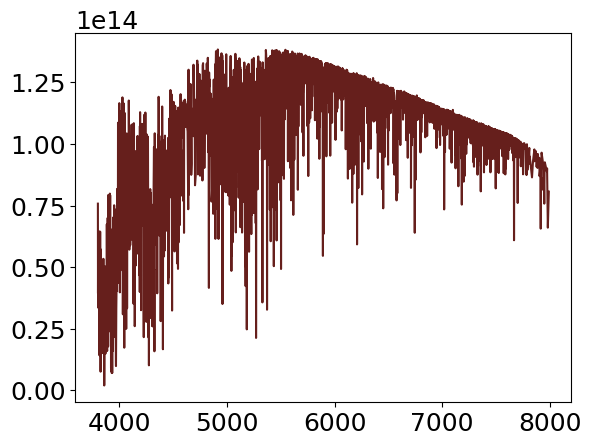

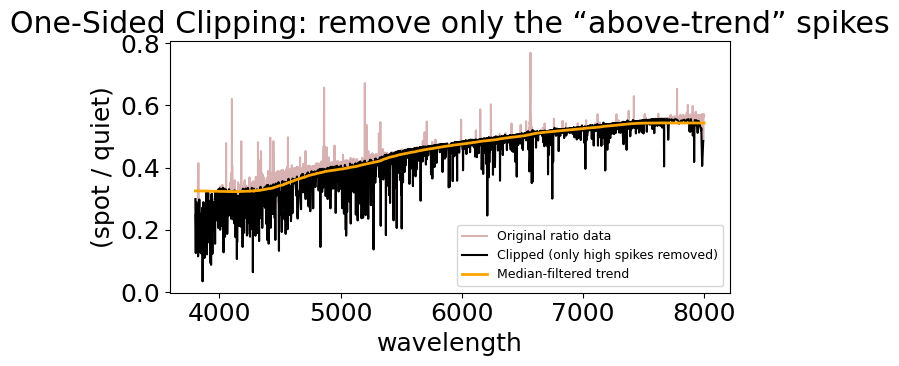

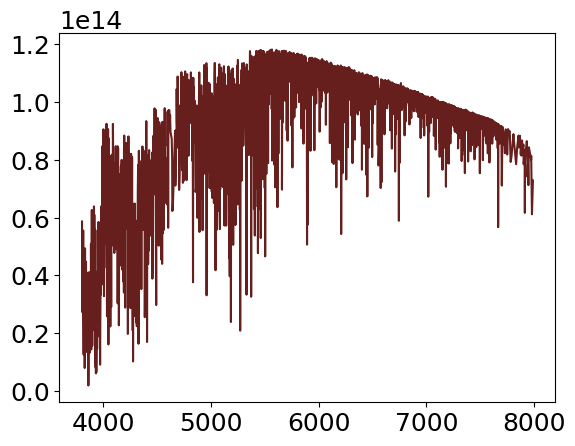

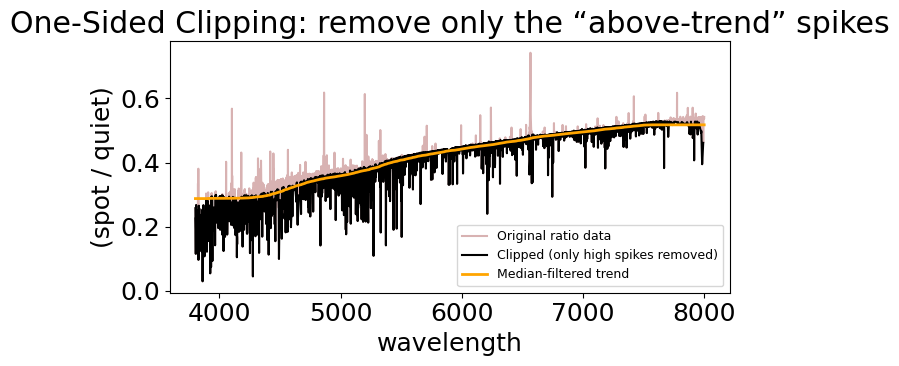

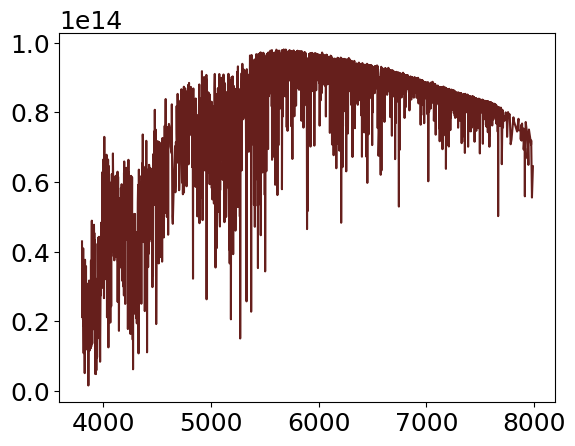

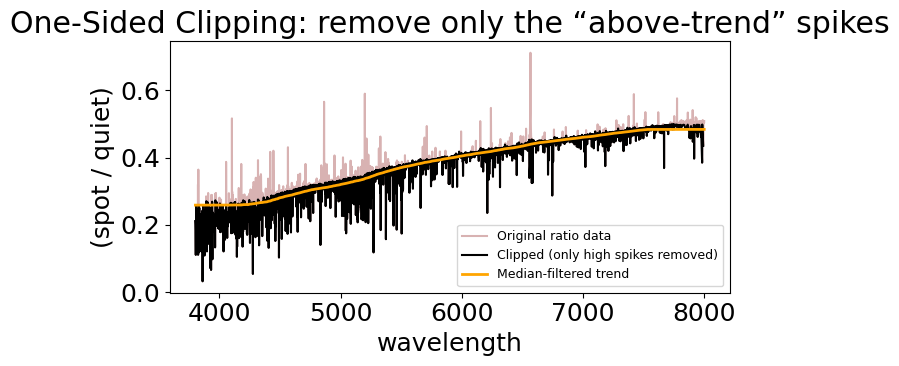

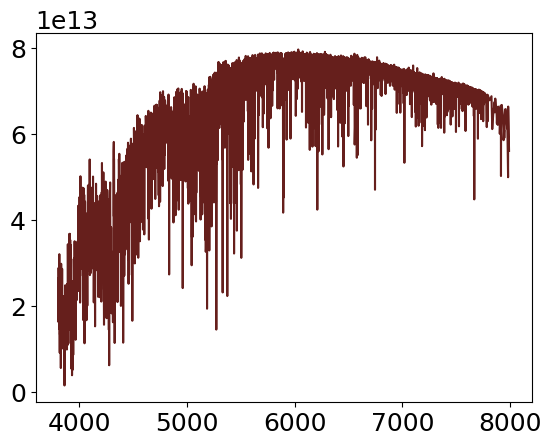

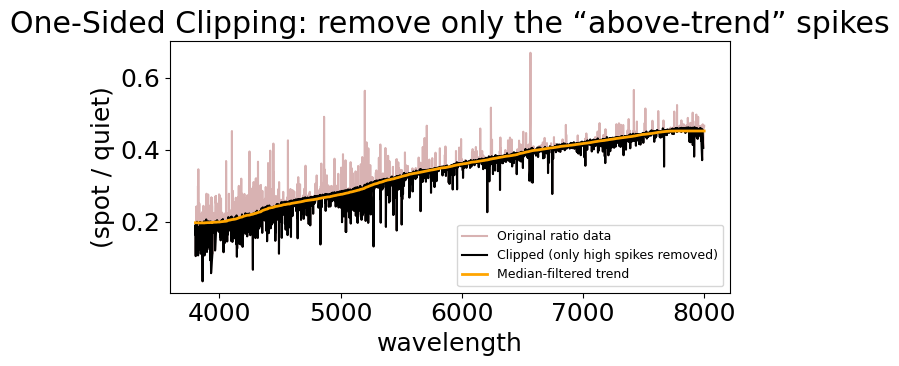

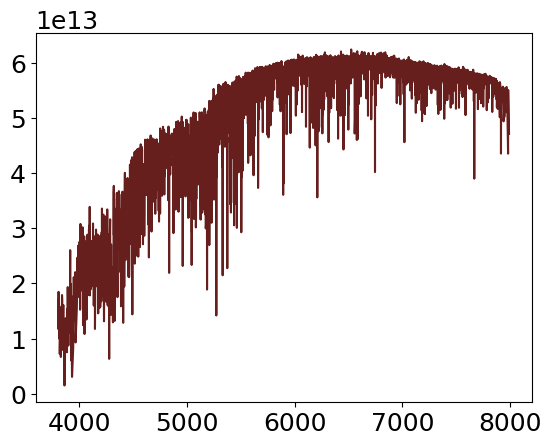

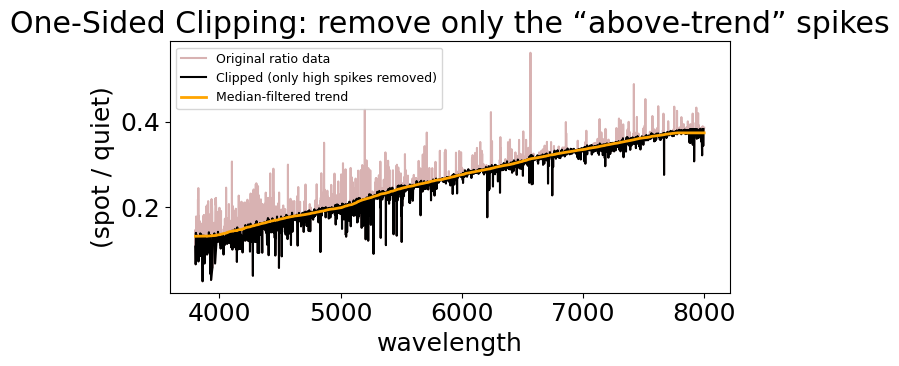

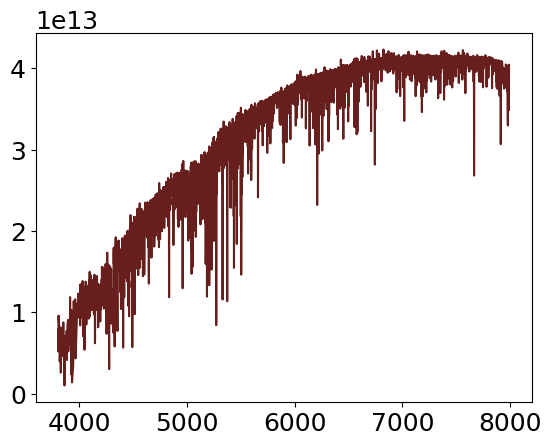

In [ ]:
from astropy.stats import sigma_clip
from scipy.ndimage import median_filter

acd = ss_mps.results['acd']

idxs = [0,1, 2, 3, 4, 5, 6, 7, 8, 9]
median_window_size_list = [3500, 3300, 3100, 3100, 2500, 2300, 2100, 2100, 1200, 1000]
N_sigma_list = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.5, 0.5, 0.7]
mask_list = []
for i in idxs:
    # Assuming you already have these arrays:
    wavelength = wav
    ratio =  low_phoenix_sp[i] / low_phoenix[i] 

    median_window_size = median_window_size_list[i]
    trend = median_filter(ratio, size=median_window_size, mode='reflect')

    # ─── Step 2: Compute residuals = (data minus trend) ───
    residual = ratio - trend

    # ─── Step 3: Compute a single σ for the residual distribution ───
    # We deliberately include all residuals when computing σ.
    sigma = np.std(residual)
    # ─── Step 4: Build a one-sided mask (only clip points FAR above) ───
    N_sigma = N_sigma_list[i]
    # Keep every point for which residual <=  N_sigma * sigma
    mask = residual <= (N_sigma * sigma)

    # If you want to iterate (to avoid a few very large spikes polluting σ):
    #    You could recompute `sigma` from only the surviving residuals, then re-mask.
    #    For example:
    # 
    mask = np.ones_like(ratio, dtype=bool)
    for _ in range(10):
        sigma = np.std(residual[mask])
        new_mask = (residual <= N_sigma * sigma)
        if new_mask.sum() == mask.sum():
            break
        mask = new_mask

    cleaned_wavelength = wavelength[mask]
    cleaned_ratio      = ratio[mask]

    # ─── Step 5: Plot original vs. clipped ───
    plt.figure(figsize=(7, 4))
    plt.plot(wavelength, ratio,
            color='maroon', alpha=0.3, label='Original ratio data')
    plt.plot(cleaned_wavelength, cleaned_ratio,
            linestyle='-', markersize=2,
            color='black', label='Clipped (only high spikes removed)')
    plt.plot(wavelength, trend, color='orange', lw=2, label='Median‐filtered trend')
    plt.xlabel('wavelength')
    plt.ylabel('(spot / quiet)')
    plt.title('One‐Sided Clipping: remove only the “above‐trend” spikes')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    plt.plot(cleaned_wavelength, cleaned_ratio * low_mps_ph[i][mask], color="#661F1C", label='cleaned')
    mask_list.append(mask)

final_mask = np.all(mask_list, axis=0)
np.savetxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/spectra_masks/lowres_mask.txt', final_mask)



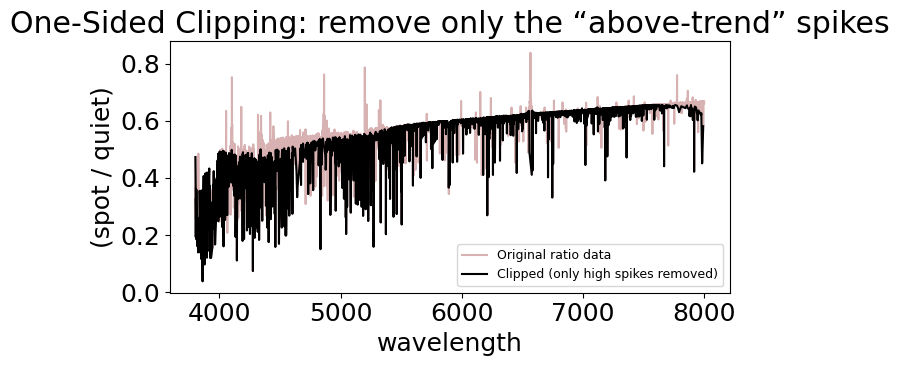

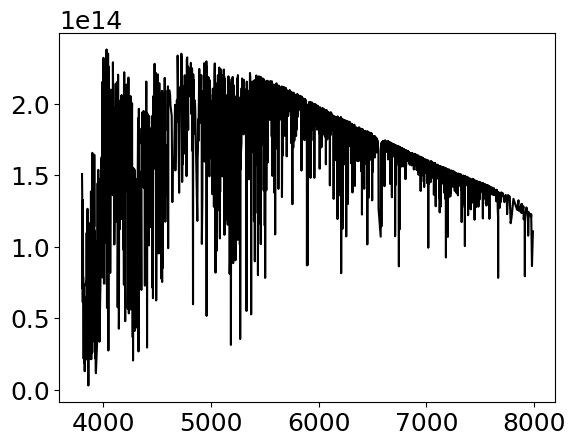

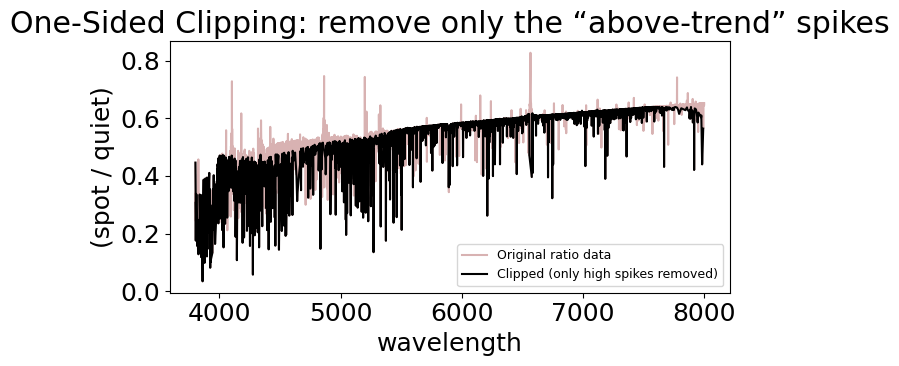

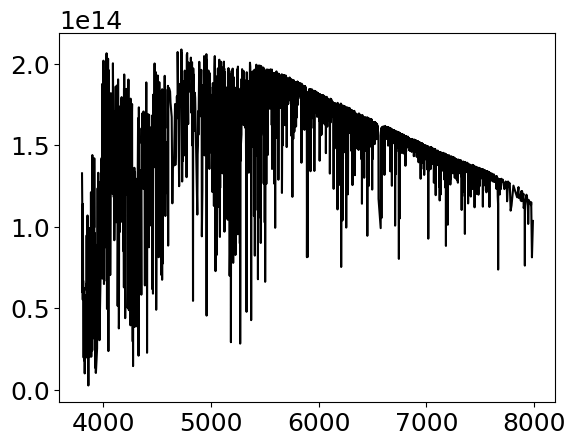

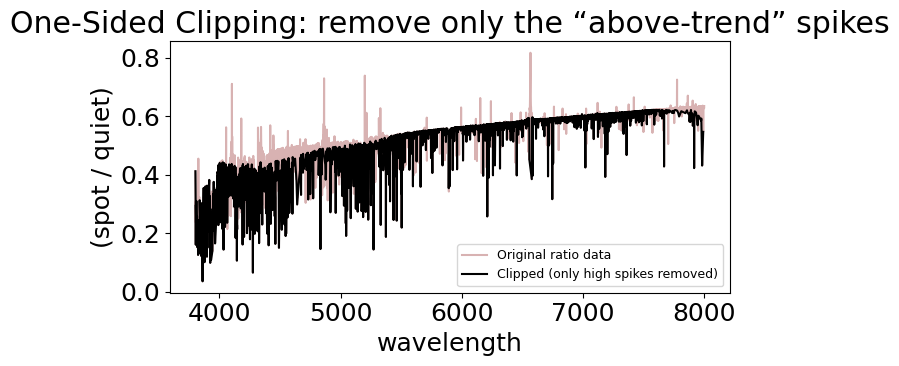

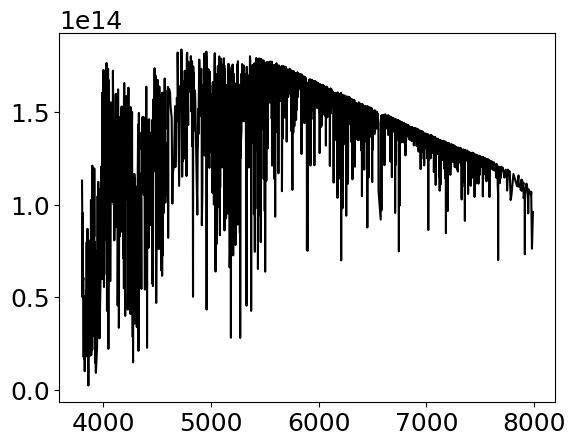

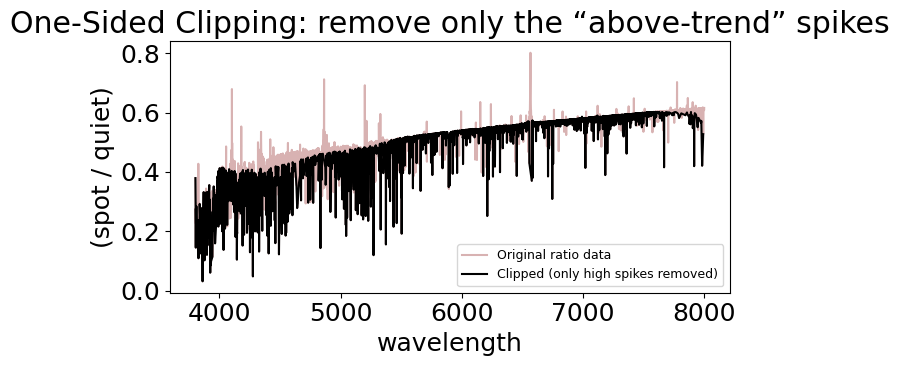

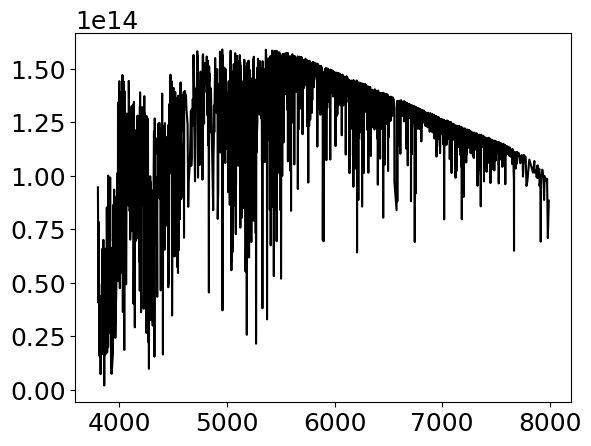

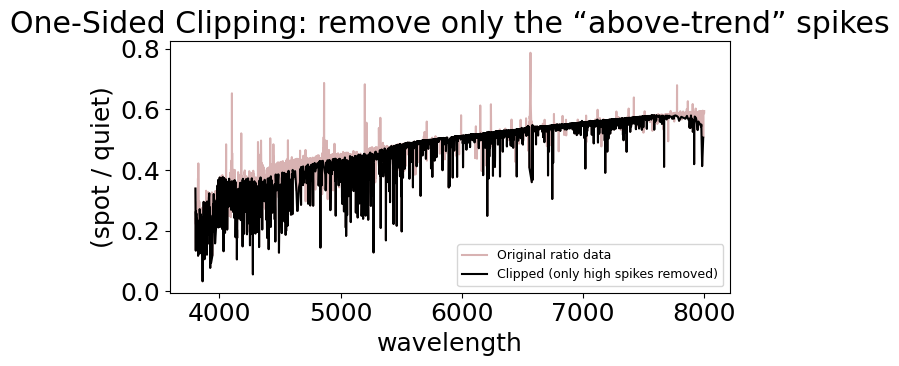

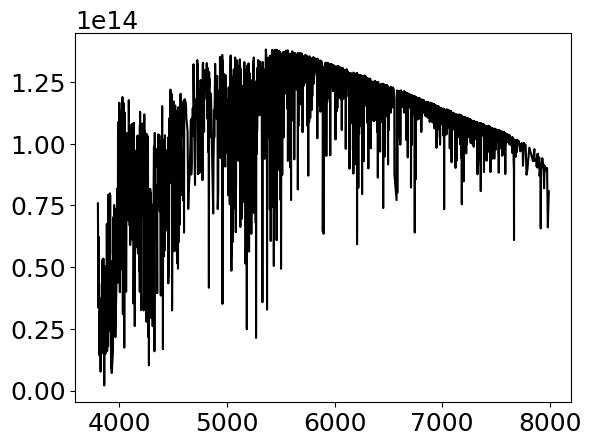

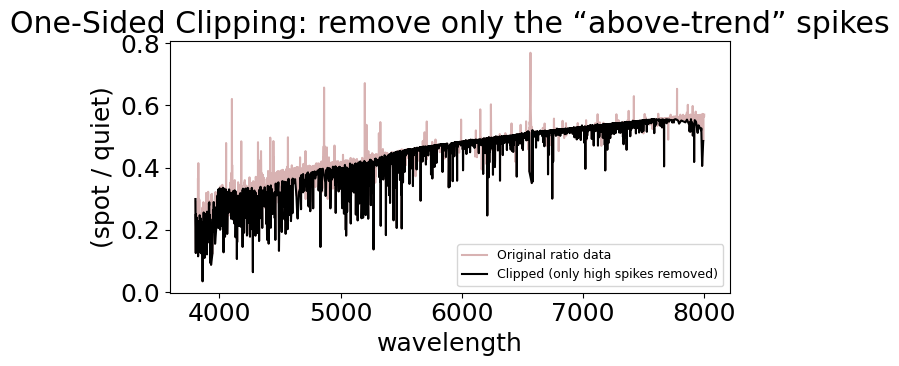

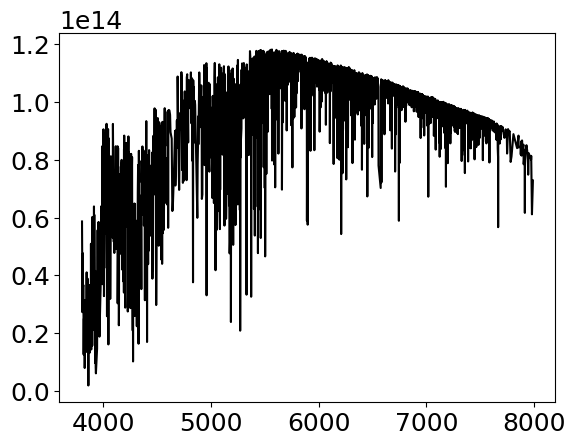

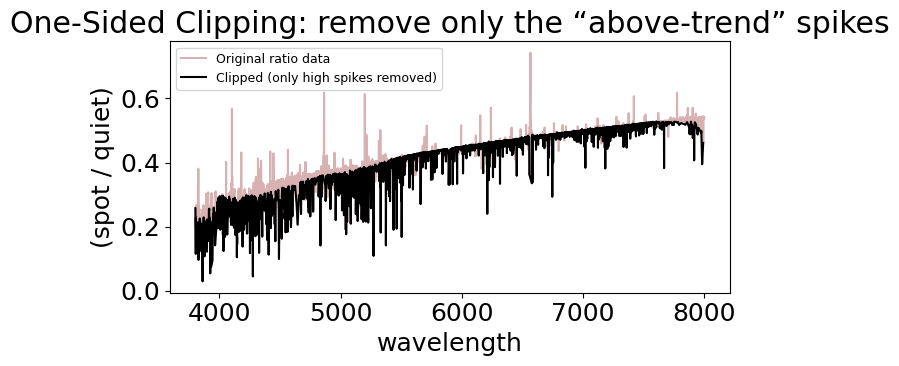

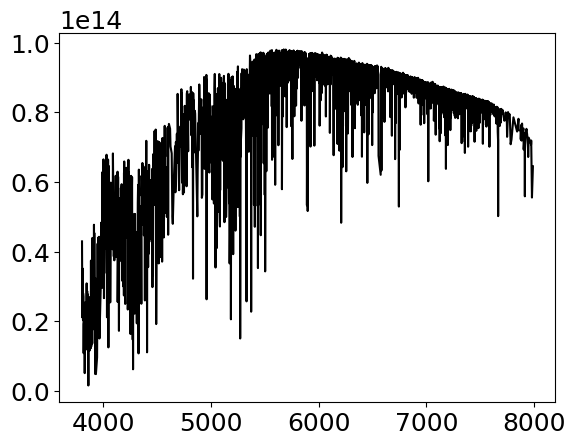

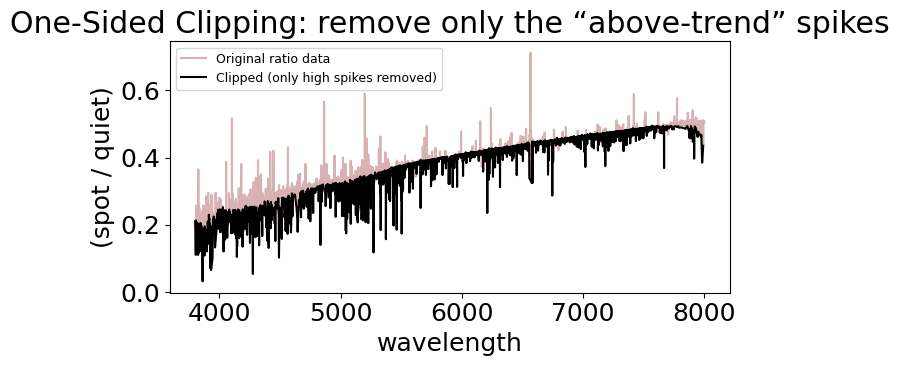

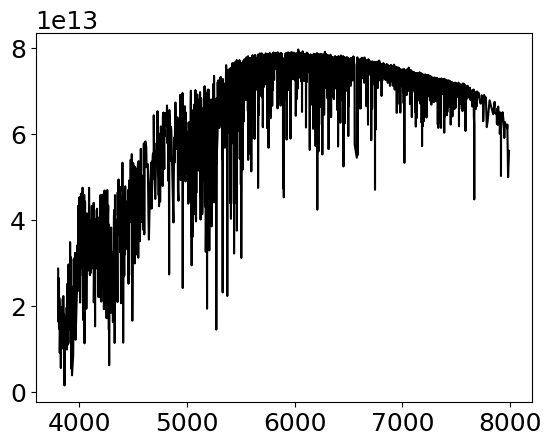

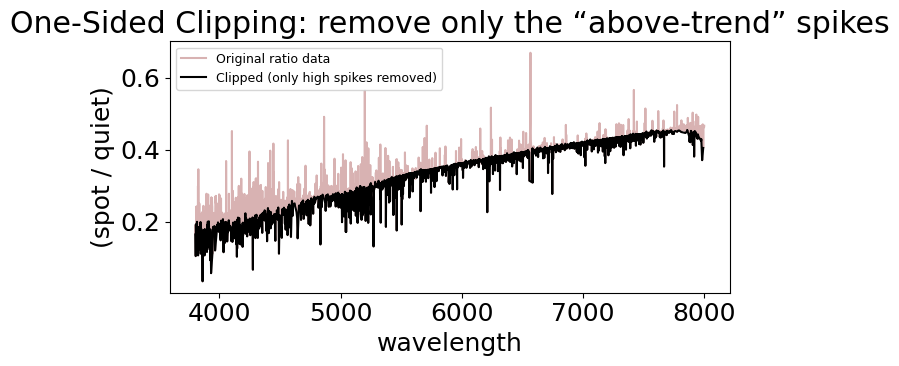

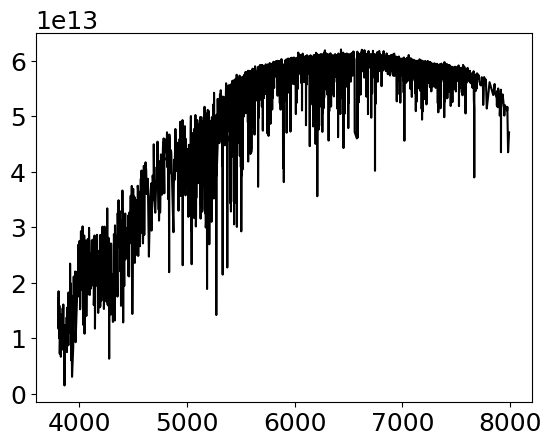

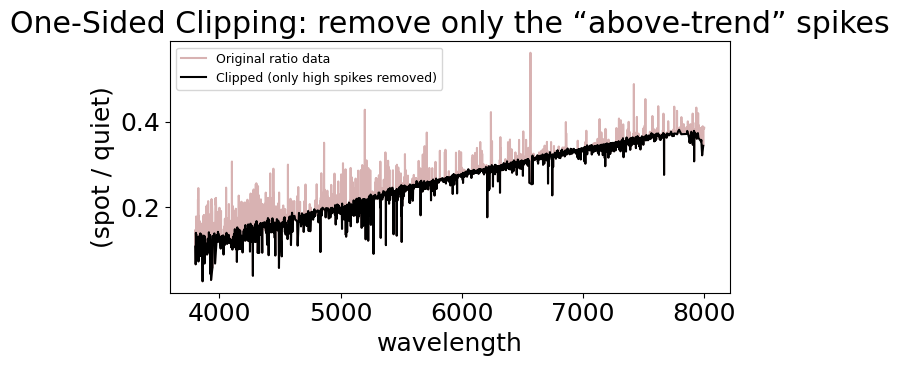

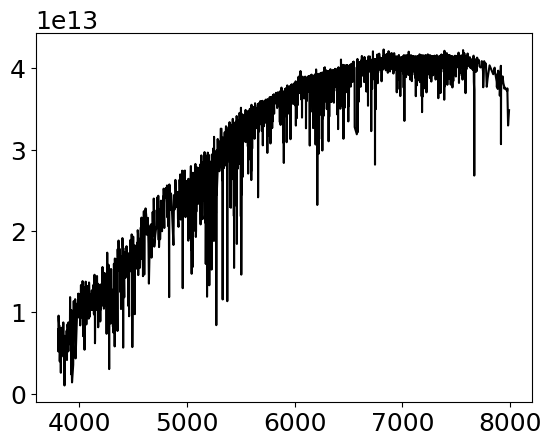

In [ ]:
for i in idxs:
    ratio =  low_phoenix_sp[i] / low_phoenix[i] 

    plt.figure(figsize=(7, 4))
    plt.plot(wavelength, ratio,
            color='maroon', alpha=0.3, label='Original ratio data')
    plt.plot(wavelength[final_mask], ratio[final_mask],
            linestyle='-', markersize=2,
            color='black', label='Clipped (only high spikes removed)')
    plt.xlabel('wavelength')
    plt.ylabel('(spot / quiet)')
    plt.title('One‐Sided Clipping: remove only the “above‐trend” spikes')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    plt.plot(wavelength[final_mask], ratio[final_mask] * low_mps_ph[i][final_mask], color='black', label='cleaned')

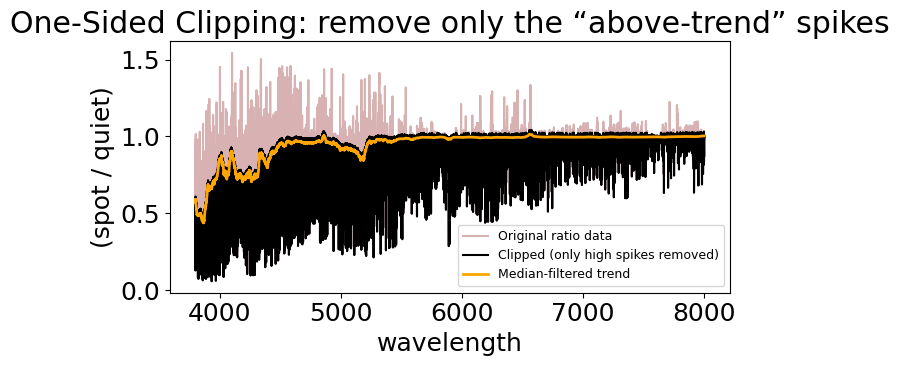

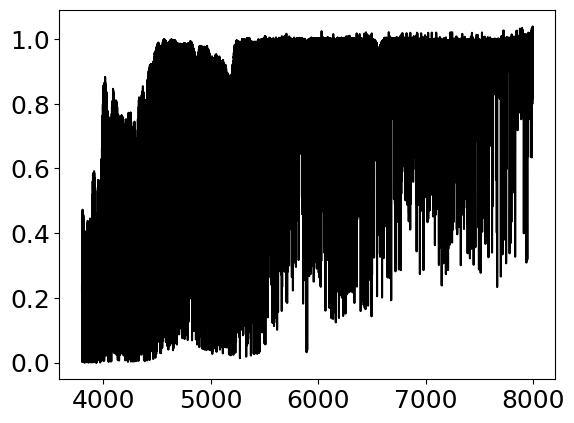

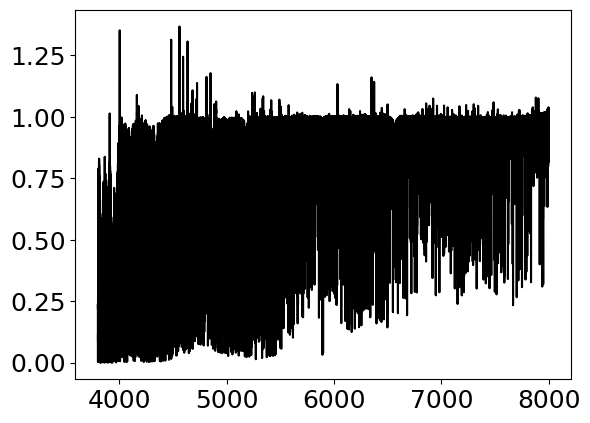

In [ ]:
wavelength = ss_mps.results['wv_rv']
ratio =  ss_mps.results['flns_rv_ph'] / ss_mps.results['flnp_rv_ph']
hires_mps = ss_mps.results['flnp_rv']

median_window_size = 5000
trend = median_filter(ratio, size=median_window_size, mode='reflect')

# ─── Step 2: Compute residuals = (data minus trend) ───
residual = ratio - trend

# ─── Step 3: Compute a single σ for the residual distribution ───
# We deliberately include all residuals when computing σ.
sigma = np.std(residual)
# ─── Step 4: Build a one-sided mask (only clip points FAR above) ───
N_sigma = 0.3
# Keep every point for which residual <=  N_sigma * sigma
mask = residual <= (N_sigma * sigma)

# If you want to iterate (to avoid a few very large spikes polluting σ):
#    You could recompute `sigma` from only the surviving residuals, then re-mask.
#    For example:
# 
mask = np.ones_like(ratio, dtype=bool)
for _ in range(10):
    sigma = np.std(residual[mask])
    new_mask = (residual <= N_sigma * sigma)
    if new_mask.sum() == mask.sum():
        break
    mask = new_mask

cleaned_wavelength = wavelength[mask]
cleaned_ratio      = ratio[mask]

# ─── Step 5: Plot original vs. clipped ───
plt.figure(figsize=(7, 4))
plt.plot(wavelength, ratio,
        color='maroon', alpha=0.3, label='Original ratio data')
plt.plot(cleaned_wavelength, cleaned_ratio,
        linestyle='-', markersize=2,
        color='black', label='Clipped (only high spikes removed)')
plt.plot(wavelength, trend, color='orange', lw=2, label='Median‐filtered trend')
plt.xlabel('wavelength')
plt.ylabel('(spot / quiet)')
plt.title('One‐Sided Clipping: remove only the “above‐trend” spikes')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.plot(cleaned_wavelength, cleaned_ratio * hires_mps[mask], color='black', label='cleaned')
plt.show()

plt.plot(wavelength, ratio * hires_mps, color='black', label='raw')
np.savetxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/spectra_masks/hires_mask.txt', mask)



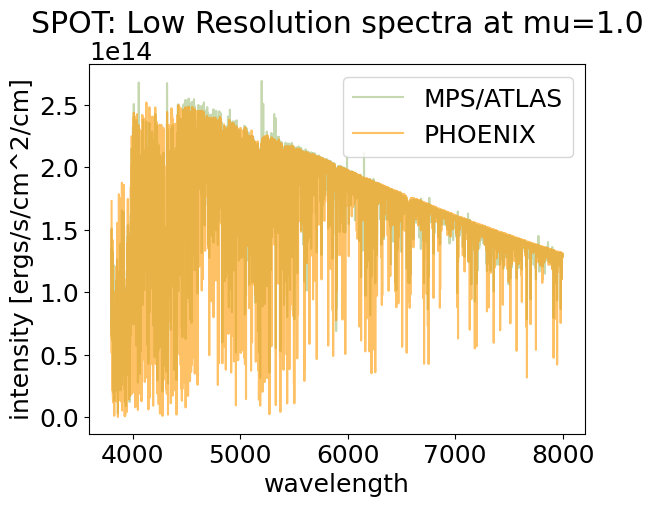

In [ ]:
plt.plot(wav, low_phoenix_sp[0] / low_phoenix[0]* low_mps_ph[0], color="#C6D8AF", label='MPS/ATLAS', alpha=1) # erg/s/cm2/A
plt.plot(wav, low_phoenix_sp[0] , color='#ff9900', label='PHOENIX', alpha = 0.6) # erg/s/cm2/cm
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('SPOT: Low Resolution spectra at mu=1.0')
plt.legend()
plt.show()